# Checkpoint 5 — Random Forest, XGBoost e LightGBM
## Detecção de Fraude em Transações de Cartão de Crédito

**Disciplina**: Data Science & Statistical Computing (FIAP, 2026)  
**Professor**: Jones Egydio  

**Base de dados**: "Credit Card Fraud Detection" (Machine Learning Group, ULB, em parceria com a Worldline; disponível no Kaggle)  
**Mirror usado**: https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv  
**Licença**: Open Database License (ODbL), conforme a página do dataset no Kaggle  
**Data de acesso**: 2026-10-08

**Integrantes**: Bernardo Moreira - RM: 564103 / Pedro Batista - RM: 563220 / Larissa Shiba - RM: 560462 / Renan Jordão - RM: 560618

**Variável resposta (y)**: `Class` — 1 indica transação fraudulenta e 0 indica transação legítima.  
**Métrica principal**: PR-AUC (Average Precision), calculada por validação cruzada estratificada sobre o conjunto de treino.

<style>
.jp-MarkdownOutput, .text_cell_render {
    font-family: "Latin Modern Roman", "CMU Serif", Georgia, "DejaVu Serif", serif;
    font-size: 18px;
    line-height: 1.6;
}
</style>

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Configuração visual:</strong> o notebook prioriza tipografia serifada para células Markdown. A renderização de CSS pode variar entre Jupyter Notebook, JupyterLab, VS Code e Google Colab; quando uma fonte não estiver disponível, o visualizador utilizará uma alternativa local. O código permanece com fonte monoespaçada do ambiente.
</div>


---
## Notação e Protocolo Experimental

Considere a base de dados como $\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{n}$, em que $\mathbf{x}_i$ são as variáveis preditoras da transação $i$ e $y_i$ é a variável-alvo. A matriz de atributos é $\mathbf{X}$ e o vetor-alvo é $\mathbf{y}$.

A separação produz $\mathcal{D}_{\mathrm{treino}}$ e $\mathcal{D}_{\mathrm{teste}}$. O conjunto de teste fica isolado durante a seleção de variáveis, a comparação dos modelos, o Grid Search, o Optuna, a escolha do limiar de decisão e a escolha do modelo final. Ele só é usado na avaliação final do Exercício 7.

Os três modelos são $M_{\mathrm{RF}}$, $M_{\mathrm{XGB}}$ e $M_{\mathrm{LGBM}}$, e $\boldsymbol{\theta}$ representa o vetor de hiperparâmetros de cada um.

**Regra de comparabilidade**: os três algoritmos usam o mesmo conjunto de teste, os mesmos folds de validação cruzada, a mesma métrica principal e o mesmo pipeline de pré-processamento. As únicas diferenças entre eles são a classe do estimador e os hiperparâmetros.

---
## 1. Imports e Configuração

Constantes globais do experimento:
- `SEED = 42` — semente única para split, validação cruzada, modelos e Optuna
- `N_FOLDS = 5` — número de folds da validação cruzada estratificada
- `N_TRIALS = 20` — número de trials do Optuna por modelo (mínimo exigido no enunciado)

In [2]:
import os
import json
import time
import warnings
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate,
    cross_val_predict,
    learning_curve,
)
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore", message="X does not have valid feature names")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
N_FOLDS = 5
N_TRIALS = 20

os.makedirs("dados", exist_ok=True)
os.makedirs("modelo", exist_ok=True)

from matplotlib import font_manager

# Fonte serifada nos gráficos, com alternativa caso a preferida não exista no ambiente
fonte_serif = "DejaVu Serif"
for fonte in ["Latin Modern Roman", "CMU Serif", "Georgia", "DejaVu Serif"]:
    try:
        font_manager.findfont(fonte, fallback_to_default=False)
        fonte_serif = fonte
        break
    except Exception:
        pass

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "serif", "font.serif": [fonte_serif, "DejaVu Serif"],
    "mathtext.fontset": "cm", "text.usetex": False,
    "figure.figsize": (10, 6), "figure.dpi": 100,
    "axes.titlesize": 14, "axes.labelsize": 12,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False,
})

print(f"SEED={SEED} | N_FOLDS={N_FOLDS} | N_TRIALS={N_TRIALS}")

c:\dev\Checkpoint-Data-Science\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SEED=42 | N_FOLDS=5 | N_TRIALS=20


---
## Exercício 1 — Definição do Problema e da Base de Dados

### 1.1 Contexto e problema

Fraude em cartão de crédito gera prejuízo direto para emissores e clientes, e o volume de transações torna inviável a revisão manual de cada operação. Um sistema de apoio à decisão precisa pontuar cada transação no momento em que ela chega e encaminhar para análise apenas as mais suspeitas.

**Pergunta**: dadas as características de uma transação (valor, momento e componentes anonimizados do comportamento do cartão), qual a probabilidade de ela ser fraudulenta?

**Por que uma solução supervisionada é adequada?** Existe um histórico rotulado, com o resultado confirmado de cada transação, e o padrão de fraude é complexo e não linear. Modelos de árvores lidam bem com interações entre variáveis e com escalas heterogêneas, o que os torna candidatos naturais para o problema.

### 1.2 Variável-alvo

- **y**: `Class` (0 = legítima, 1 = fraude)
- **Tipo de problema**: classificação binária, com desbalanceamento extremo
- **Significado de $\hat{y}$**: a previsão é a probabilidade estimada de fraude pelo modelo, convertida em decisão (alertar ou não) por um limiar escolhido apenas com dados de treino. No domínio, $\hat{y}=1$ significa que a transação deve ser encaminhada para revisão ou bloqueio.

### 1.3 Base de dados

- **Fonte**: Machine Learning Group (ULB) e Worldline, publicada no Kaggle como "Credit Card Fraud Detection"
- **Obtenção**: download automático pelo notebook a partir do mirror público do TensorFlow, sem autenticação
- **Unidade observacional**: uma transação de cartão de crédito
- **Contexto**: transações realizadas por portadores europeus durante dois dias de setembro de 2013
- **Dimensões iniciais**: 284.807 linhas × 31 colunas, com 492 fraudes (cerca de 0,172%)
- **Privacidade**: as variáveis `V1` a `V28` são componentes principais (PCA) calculados pelo provedor, por confidencialidade. Não há dados pessoais identificáveis.

| # | Variável | Tipo | Descrição |
|---|----------|------|-----------|
| 1 | `Time` | Contínua | Segundos decorridos desde a primeira transação da base |
| 2–29 | `V1` a `V28` | Contínua | Componentes principais anonimizados |
| 30 | `Amount` | Contínua | Valor da transação |
| 31 | `Class` | Binária | Alvo: 1 = fraude, 0 = legítima |

### 1.4 Critério de sucesso

**Métrica principal: PR-AUC (Average Precision)**. Com fraudes representando cerca de 0,17% das transações, a acurácia é inútil: um modelo que sempre responde "legítima" acerta mais de 99,8% dos casos e não detecta nenhuma fraude. A ROC-AUC também tende a ser otimista nesse cenário, pois a enorme quantidade de negativos mantém a taxa de falsos positivos baixa mesmo quando a precisão é ruim. A PR-AUC resume o equilíbrio entre precision e recall sobre a classe positiva e tem como referência de modelo aleatório a própria prevalência da fraude.

**Métricas auxiliares**: ROC-AUC, Precision, Recall, F1 e MCC (Matthews), as quatro últimas calculadas em um limiar de decisão escolhido somente no treino.

In [3]:
URL_BASE = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
CAMINHO_BRUTA = "dados/base_bruta.csv"

if not os.path.exists(CAMINHO_BRUTA):
    print("Baixando base bruta...")
    with requests.get(URL_BASE, stream=True, timeout=60) as resp:
        resp.raise_for_status()
        with open(CAMINHO_BRUTA + ".tmp", "wb") as f:
            for bloco in resp.iter_content(chunk_size=1024 * 1024):
                f.write(bloco)
    os.replace(CAMINHO_BRUTA + ".tmp", CAMINHO_BRUTA)
    print(f"Salvo em {CAMINHO_BRUTA} ({os.path.getsize(CAMINHO_BRUTA) / 1e6:,.1f} MB)")
else:
    print(f"Base bruta já existe em {CAMINHO_BRUTA}, pulando download.")

df = pd.read_csv(CAMINHO_BRUTA)

print(f"\nShape: {df.shape}")
print(f"Colunas: {list(df.columns)}")
df.head()

Baixando base bruta...
Salvo em dados/base_bruta.csv (150.8 MB)

Shape: (284807, 31)
Colunas: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Frequência das classes:
  Class = 0 (legítima): 284,315 (99.827%)
  Class = 1 (fraude): 492 (0.173%)

Razão legítimas/fraudes: 577.9 para 1


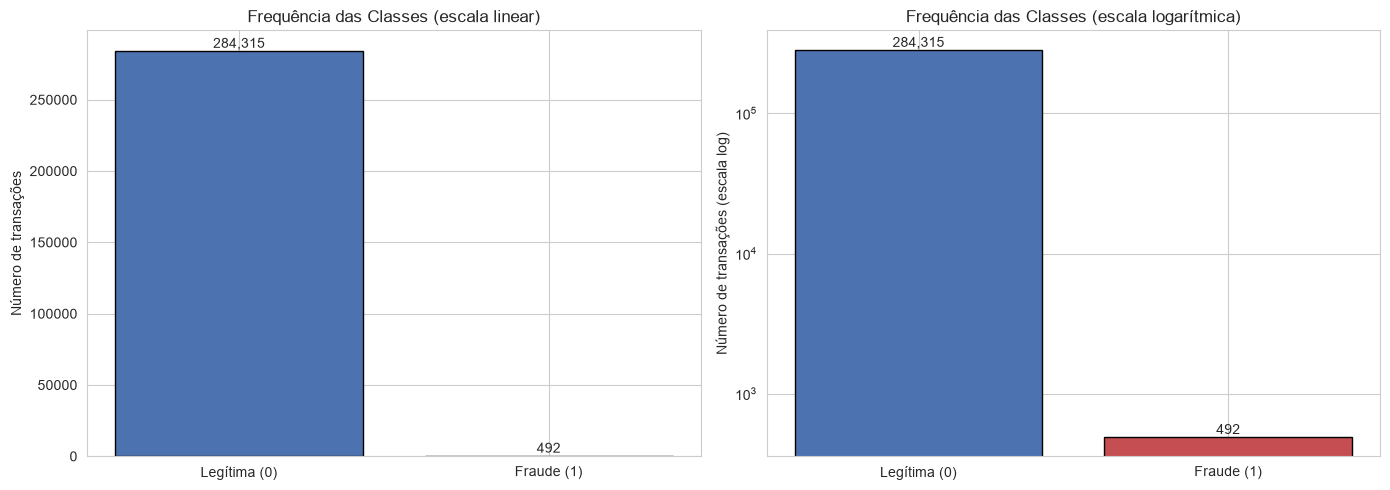

In [4]:
contagem = df["Class"].value_counts().sort_index()
proporcao = df["Class"].value_counts(normalize=True).sort_index()

print("Frequência das classes:")
for classe in contagem.index:
    rotulo = "fraude" if classe == 1 else "legítima"
    print(f"  Class = {classe} ({rotulo}): {contagem[classe]:,} ({proporcao[classe] * 100:.3f}%)")

print(f"\nRazão legítimas/fraudes: {contagem[0] / contagem[1]:.1f} para 1")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(["Legítima (0)", "Fraude (1)"], contagem.values, color=["#4C72B0", "#C44E52"], edgecolor="black")
axes[0].set_ylabel("Número de transações")
axes[0].set_title("Frequência das Classes (escala linear)")
for i, v in enumerate(contagem.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[1].bar(["Legítima (0)", "Fraude (1)"], contagem.values, color=["#4C72B0", "#C44E52"], edgecolor="black")
axes[1].set_yscale("log")
axes[1].set_ylabel("Número de transações (escala log)")
axes[1].set_title("Frequência das Classes (escala logarítmica)")
for i, v in enumerate(contagem.values):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

**Interpretação**: a classe positiva é uma fração mínima da base. Na escala linear a barra das fraudes é praticamente invisível, e a escala logarítmica é necessária para enxergá-la. Esse desbalanceamento define três decisões do projeto: a métrica principal é PR-AUC, os splits e os folds são estratificados, e o limiar de decisão não pode ser fixado em 0,5 sem análise.

---
## Exercício 2 — Data Wrangling e Análise Exploratória

Etapas:
1. Diagnóstico de qualidade (tipos, ausências, duplicidades, valores impossíveis)
2. Remoção de duplicatas exatas
3. Derivação de `hora_relativa` a partir de `Time`
4. Análise exploratória
5. Verificação final e exportação da base tratada

### 2.1 Diagnóstico de qualidade

In [5]:
print(f"Shape original: {df.shape}")
print(f"\nNulos por coluna (total): {df.isnull().sum().sum()}")
print(f"\nDuplicatas exatas: {df.duplicated().sum()}")
print(f"\nTipos de dados:\n{df.dtypes.value_counts()}")
print(f"\nValores distintos de Class: {sorted(df['Class'].unique())}")
print(f"\nTransações com Amount negativo: {(df['Amount'] < 0).sum()}")
print(f"Transações com Amount igual a zero: {(df['Amount'] == 0).sum()}")
print(f"Time mínimo: {df['Time'].min():,.0f} s | Time máximo: {df['Time'].max():,.0f} s ({df['Time'].max() / 3600:.1f} h)")

df[["Time", "Amount"]].describe()

Shape original: (284807, 31)

Nulos por coluna (total): 0

Duplicatas exatas: 1081

Tipos de dados:
float64    30
int64       1
Name: count, dtype: int64

Valores distintos de Class: [np.int64(0), np.int64(1)]

Transações com Amount negativo: 0
Transações com Amount igual a zero: 1825
Time mínimo: 0 s | Time máximo: 172,792 s (48.0 h)


,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


**Interpretação**: todas as colunas são numéricas e não há valores ausentes. A coluna `Class` contém somente 0 e 1, e não há valores monetários negativos. Transações com valor zero existem e são plausíveis em operações de verificação de cartão, portanto não são tratadas como erro. O diagnóstico aponta duplicatas exatas, tratadas a seguir. As categorias não são um problema aqui porque a base não possui colunas textuais.

### 2.2 Remoção de duplicatas

Linhas idênticas em todas as 31 colunas, incluindo `Time` e os 28 componentes contínuos, indicam registros repetidos. Além de inflar o volume, duplicatas podem cair em treino e teste ao mesmo tempo e inflar artificialmente as métricas de generalização.  
**Decisão**: remover as duplicatas exatas **antes** do split, mantendo a primeira ocorrência. Essa operação não aprende parâmetros da amostra, portanto não gera vazamento.

In [6]:
n_antes = len(df)
fraudes_antes = int(df["Class"].sum())

df = df.drop_duplicates().reset_index(drop=True)

n_depois = len(df)
fraudes_depois = int(df["Class"].sum())

print(f"Removidas {n_antes - n_depois} duplicatas exatas.")
print(f"Fraudes removidas junto com as duplicatas: {fraudes_antes - fraudes_depois}")
print(f"Shape após deduplicação: {df.shape}")
print(f"Prevalência de fraude após deduplicação: {df['Class'].mean() * 100:.3f}%")

Removidas 1081 duplicatas exatas.
Fraudes removidas junto com as duplicatas: 19
Shape após deduplicação: (283726, 31)
Prevalência de fraude após deduplicação: 0.167%


### 2.3 Derivação de `hora_relativa`

`Time` é um contador de segundos desde a primeira transação da base. Ele depende da janela de captura do dataset e não representa um instante que um sistema em produção conheça da mesma forma. Usá-lo cru permitiria ao modelo memorizar posições específicas dessa janela de dois dias, o que não generaliza para novas transações.

**Decisão**: derivar `hora_relativa = (Time mod 86400) // 3600`, que resulta na hora do ciclo diário (0 a 23) relativa ao início da captura, e **excluir `Time`**. A variável preserva o padrão cíclico diário, que é informação reutilizável, e descarta a posição absoluta na janela. A transformação é determinística linha a linha e não aprende nada da amostra.

In [7]:
df["hora_relativa"] = ((df["Time"] % 86400) // 3600).astype(int)

print(f"hora_relativa — valores distintos: {sorted(df['hora_relativa'].unique())}")
print(f"\nTransações por hora relativa:")
print(df["hora_relativa"].value_counts().sort_index().to_string())

hora_relativa — valores distintos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]

Transações por hora relativa:
hora_relativa
0      7647
1      4208
2      3308
3      3487
4      2204
5      2988
6      4082
7      7233
8     10232
9     15767
10    16548
11    16781
12    15378
13    15323
14    16520
15    16374
16    16396
17    16130
18    16959
19    15566
20    16705
21    17629
22    15378
23    10883


### 2.4 Decisões sobre `Amount` e `V1`–`V28`

- **`Amount`**: apresenta cauda longa e valores extremos. **Não removemos outliers.** Valores altos podem ser exatamente o padrão procurado em fraudes, e remover linhas pela cauda eliminaria sinal além de distorcer a prevalência. Modelos baseados em árvores são invariantes a transformações monotônicas, então também não aplicamos log ou padronização.
- **`V1`–`V28`**: já são componentes de PCA, centrados e sem escala comum relevante para árvores. Nada é alterado.
- **Ausências**: não existem, mas o pipeline de modelagem incluirá `SimpleImputer(strategy="median")` como proteção. Ele é ajustado apenas dentro dos folds de treino, o que evita vazamento caso a base futura contenha nulos.

### 2.5 Análise exploratória (EDA)

A EDA é descritiva e feita para compreender $\mathbf{X}$ e $\mathbf{y}$. Nenhuma variável é criada ou removida com base nas estatísticas calculadas aqui, e a seleção de variáveis do Exercício 3 usa apenas critérios de domínio.

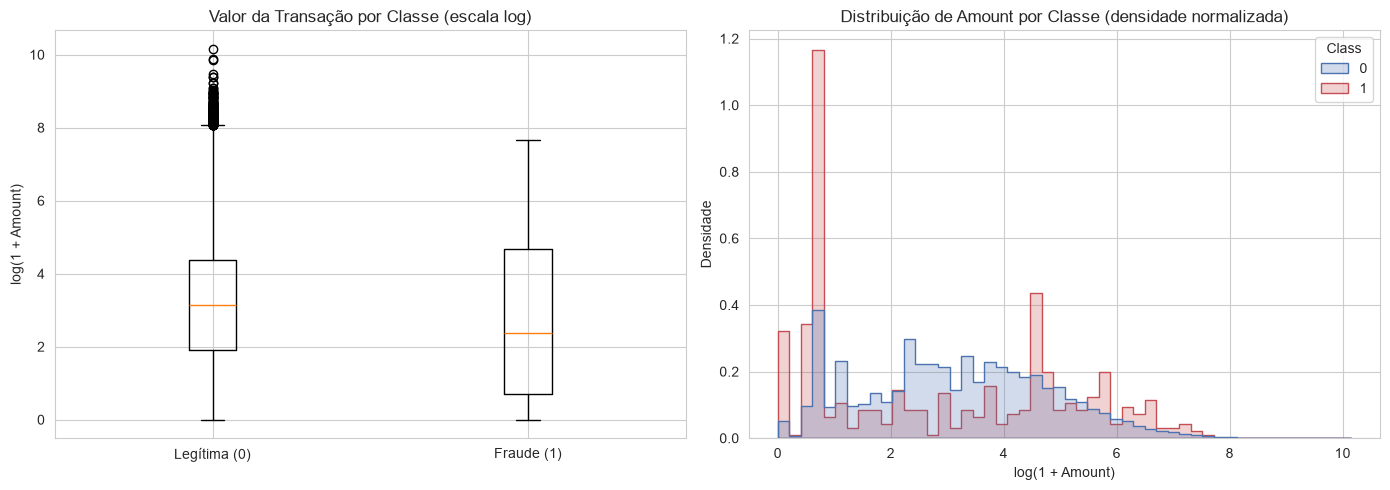

Estatísticas de Amount por classe:
          count    mean    50%       max
Class                                   
0      283253.0   88.41  22.00  25691.16
1         473.0  123.87   9.82   2125.87


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dados_box = [np.log1p(df.loc[df["Class"] == 0, "Amount"]), np.log1p(df.loc[df["Class"] == 1, "Amount"])]
axes[0].boxplot(dados_box, tick_labels=["Legítima (0)", "Fraude (1)"], showfliers=True)
axes[0].set_ylabel("log(1 + Amount)")
axes[0].set_title("Valor da Transação por Classe (escala log)")

sns.histplot(data=df.assign(log_amount=np.log1p(df["Amount"])), x="log_amount", hue="Class",
             stat="density", common_norm=False, bins=50, element="step", ax=axes[1],
             palette={0: "#4C72B0", 1: "#C44E52"})
axes[1].set_xlabel("log(1 + Amount)")
axes[1].set_ylabel("Densidade")
axes[1].set_title("Distribuição de Amount por Classe (densidade normalizada)")

plt.tight_layout()
plt.show()

print("Estatísticas de Amount por classe:")
print(df.groupby("Class")["Amount"].describe()[["count", "mean", "50%", "max"]].round(2).to_string())

**Interpretação**: `Amount` tem cauda longa nas duas classes, o que justifica o uso da escala logarítmica para visualização. Compare as medianas impressas: se elas diferem entre as classes, o valor carrega algum sinal, mas a sobreposição das distribuições mostra que `Amount` sozinho não separa fraudes de transações legítimas. É um preditor fraco isoladamente e deve ser combinado aos demais.

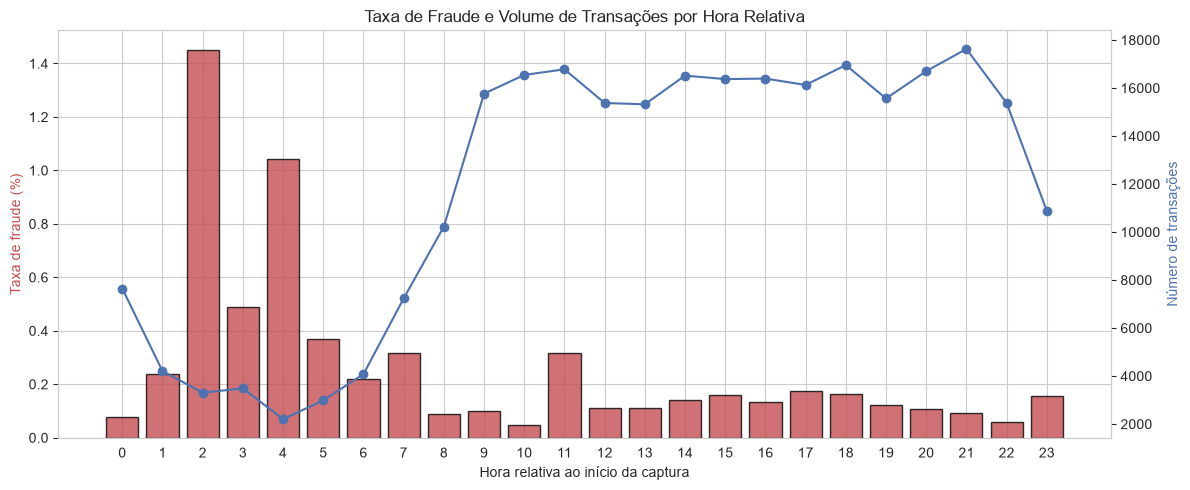

Hora com maior taxa de fraude: 2 (1.451%)
Taxa média geral: 0.167%


In [9]:
por_hora = df.groupby("hora_relativa")["Class"].agg(["mean", "sum", "count"])
por_hora["taxa_fraude_pct"] = por_hora["mean"] * 100

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(por_hora.index, por_hora["taxa_fraude_pct"], color="#C44E52", alpha=0.8, edgecolor="black")
ax1.set_xlabel("Hora relativa ao início da captura")
ax1.set_ylabel("Taxa de fraude (%)", color="#C44E52")
ax1.set_xticks(range(24))

ax2 = ax1.twinx()
ax2.plot(por_hora.index, por_hora["count"], color="#4C72B0", marker="o")
ax2.set_ylabel("Número de transações", color="#4C72B0")
ax2.grid(False)

ax1.set_title("Taxa de Fraude e Volume de Transações por Hora Relativa")
plt.tight_layout()
plt.show()

print(f"Hora com maior taxa de fraude: {int(por_hora['taxa_fraude_pct'].idxmax())} ({por_hora['taxa_fraude_pct'].max():.3f}%)")
print(f"Taxa média geral: {df['Class'].mean() * 100:.3f}%")

**Interpretação**: o volume de transações segue um ciclo diário claro, com queda nas horas de menor movimento. A taxa de fraude varia entre as horas, e as faixas com poucas transações apresentam taxas instáveis, porque poucas fraudes bastam para mudar o percentual. Isso torna `hora_relativa` um sinal possível, porém ruidoso, e reforça a escolha de validar o resultado por validação cruzada em vez de confiar em padrões visuais.

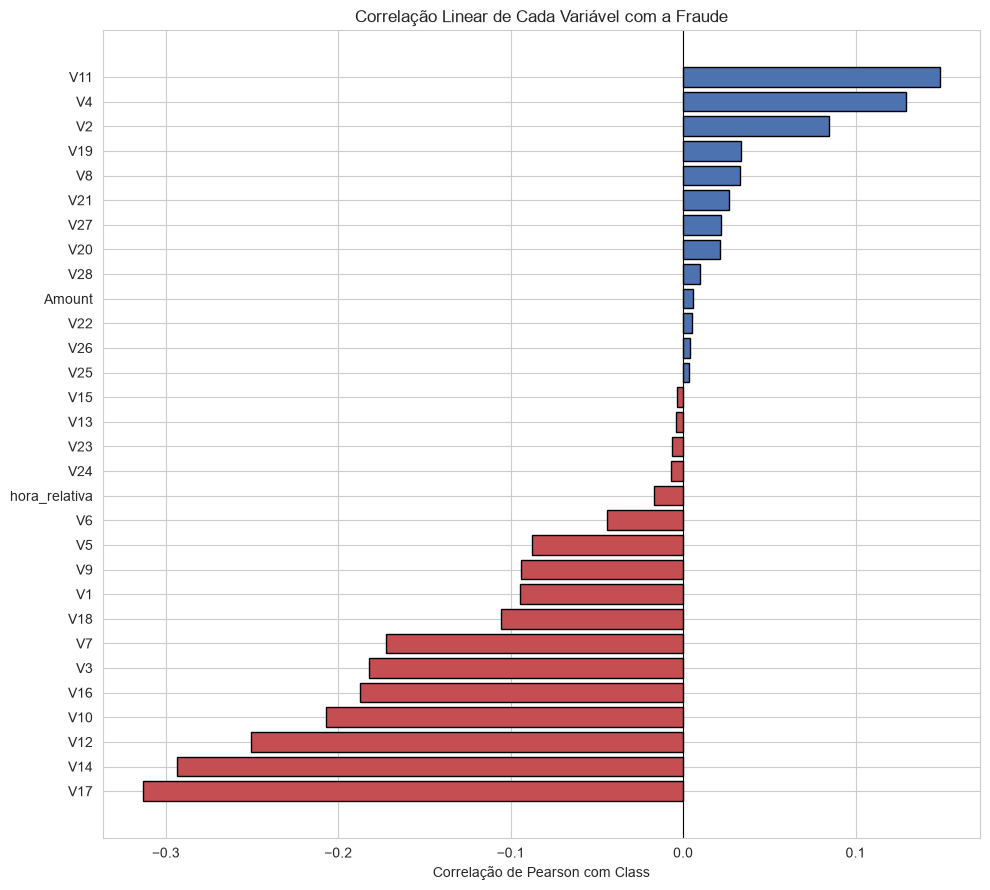

Seis maiores correlações em valor absoluto com Class:
V17   -0.313
V14   -0.293
V12   -0.251
V10   -0.207
V16   -0.187
V3    -0.182


In [10]:
colunas_V = [f"V{i}" for i in range(1, 29)]
corr_alvo = df[colunas_V + ["Amount", "hora_relativa"]].corrwith(df["Class"]).sort_values()

fig, ax = plt.subplots(figsize=(10, 9))
cores = ["#C44E52" if v < 0 else "#4C72B0" for v in corr_alvo.values]
ax.barh(corr_alvo.index, corr_alvo.values, color=cores, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlação de Pearson com Class")
ax.set_title("Correlação Linear de Cada Variável com a Fraude")
plt.tight_layout()
plt.show()

top_abs = corr_alvo.abs().sort_values(ascending=False).head(6)
print("Seis maiores correlações em valor absoluto com Class:")
print(corr_alvo[top_abs.index].round(3).to_string())

**Interpretação**: algumas componentes se destacam com correlação linear moderada com a fraude, enquanto a maioria fica próxima de zero. Como o PCA foi calculado pelo provedor sem o rótulo, é natural que apenas parte das componentes concentre o padrão de fraude. A correlação de Pearson captura apenas relações lineares e monotônicas, e os modelos de árvores podem aproveitar também interações e efeitos não lineares. Por isso **não usamos esse ranking para remover variáveis**: todas as 30 variáveis seguem para a modelagem.

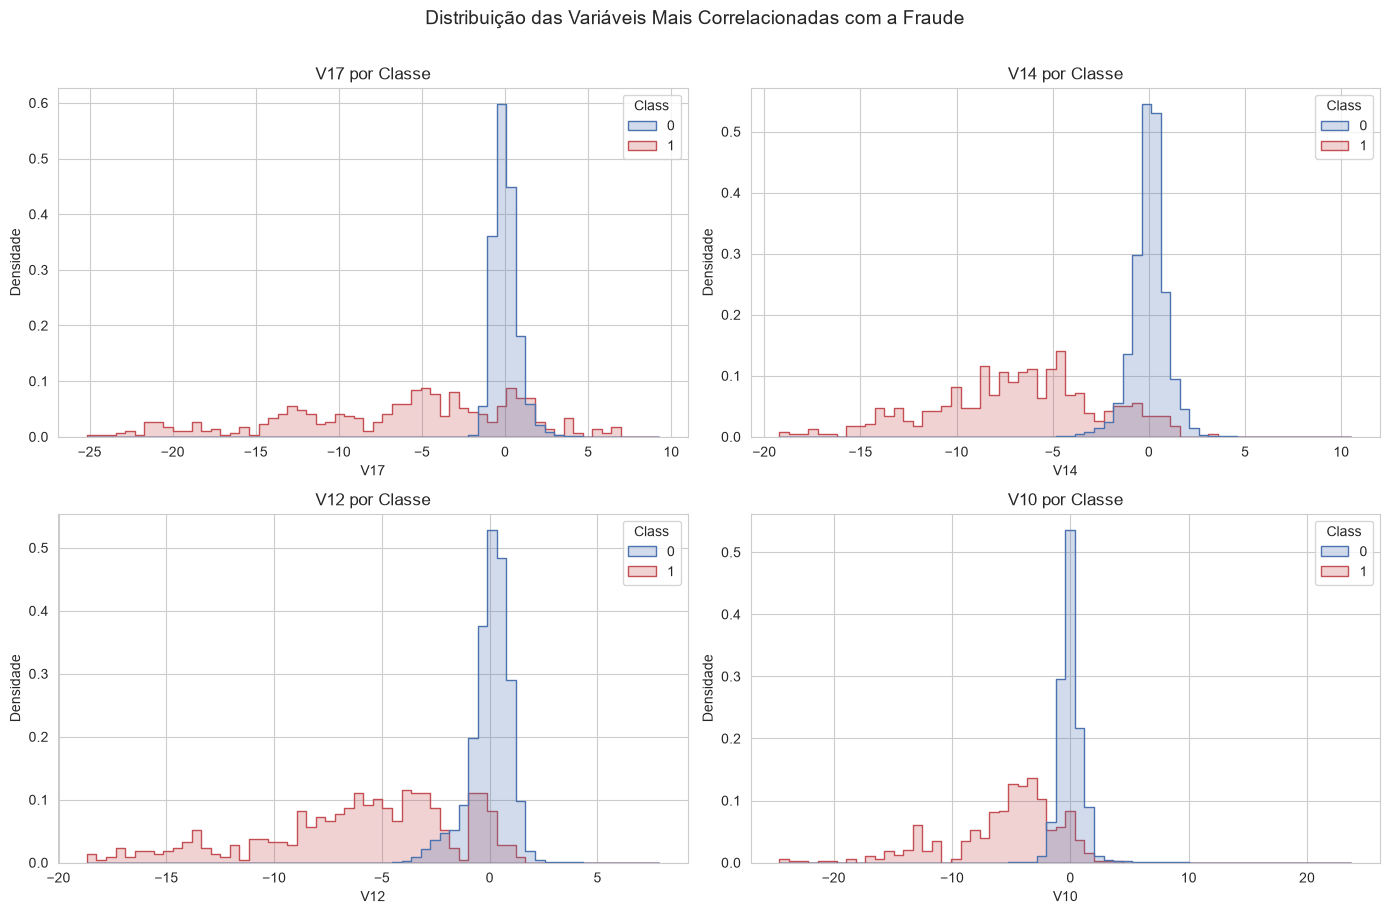

In [11]:
top4 = list(top_abs.index[:4])
top4 = [c for c in top4 if c in colunas_V][:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, var in zip(axes, top4):
    sns.histplot(data=df, x=var, hue="Class", stat="density", common_norm=False, bins=60,
                 element="step", ax=ax, palette={0: "#4C72B0", 1: "#C44E52"})
    ax.set_title(f"{var} por Classe")
    ax.set_ylabel("Densidade")

plt.suptitle("Distribuição das Variáveis Mais Correlacionadas com a Fraude", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Interpretação**: nas variáveis mais associadas ao alvo, a distribuição das fraudes se desloca claramente em relação à das transações legítimas, com região de baixa sobreposição. Esse deslocamento é o que permite ao modelo separar as classes. Como a classe positiva é pequena, suas curvas são mais irregulares, e a normalização por densidade (`common_norm=False`) foi usada para que a comparação de formas não seja dominada pelo tamanho das classes.

### 2.6 Base final e exportação

Seleção das colunas de modelagem, verificação final de ausências e duplicidades e exportação da base tratada.

In [12]:
colunas_X = colunas_V + ["Amount", "hora_relativa"]
coluna_y = "Class"

df_final = df[colunas_X + [coluna_y]].copy()

print(f"Shape base tratada: {df_final.shape}")
print(f"Nulos: {df_final.isnull().sum().sum()}")
print(f"Duplicatas exatas após o tratamento: {df_final.duplicated().sum()}")
print(f"Fraudes: {int(df_final[coluna_y].sum())} ({df_final[coluna_y].mean() * 100:.3f}%)")

CAMINHO_TRATADA = "dados/base_tratada.csv"
df_final.to_csv(CAMINHO_TRATADA, index=False)
print(f"\nBase tratada salva em {CAMINHO_TRATADA} ({len(df_final):,} linhas, {df_final.shape[1]} colunas)")

Shape base tratada: (283726, 31)
Nulos: 0
Duplicatas exatas após o tratamento: 2804
Fraudes: 473 (0.167%)

Base tratada salva em dados/base_tratada.csv (283,726 linhas, 31 colunas)


**Decisões que ficam dentro do pipeline de modelagem**: a imputação por mediana (`SimpleImputer`) aprende parâmetros da amostra e por isso é ajustada apenas nos folds de treino, dentro do `Pipeline`, para não vazar informação do teste. Nenhuma outra transformação aprende parâmetros: `hora_relativa` é determinística linha a linha e os modelos de árvores dispensam padronização e codificação.


**Verificação**: a base tratada não contém ausências. Após o tratamento das duplicatas exatas, podem restar linhas que não são idênticas em todas as colunas, o que é esperado, pois os componentes contínuos tornam transações distintas praticamente únicas.

**Decisões que permanecem para dentro do pipeline de modelagem**: a imputação por mediana (ajustada somente com dados de treino de cada fold) e qualquer outra transformação que aprenda parâmetros da amostra. Nenhuma estatística de teste participa dessas etapas.

---
## Exercício 3 — Escolha de Variáveis e Desenho Experimental

### 3.1 Definição de X e y e análise de vazamento

| Item | Decisão | Justificativa |
|------|---------|---------------|
| `Class` | **y** (alvo) | Rótulo de fraude confirmada |
| `V1`–`V28` | **X** (mantidas) | Componentes disponíveis no momento da transação |
| `Amount` | **X** (mantida) | Valor conhecido no momento da autorização |
| `hora_relativa` | **X** (mantida) | Derivada de `Time`, representa o ciclo diário |
| `Time` | **Removida** | Contador absoluto dependente da janela de captura da base; substituída por `hora_relativa` |

**Análise de data leakage**:
- A base não possui identificadores de transação, de cliente ou de cartão.
- Não há campos gerados após o evento (estorno, resultado de investigação, status da disputa) que revelem o alvo diretamente.
- **Ressalva metodológica**: `V1`–`V28` foram obtidas por PCA calculado pelo provedor sobre a base inteira, sem uso do rótulo. É um vazamento transdutivo leve e inevitável, pois as variáveis originais não são públicas e o PCA não pode ser refeito apenas com o treino. Como o PCA é não supervisionado, o risco de contaminar o teste com informação do alvo é baixo, mas a limitação é registrada para a interpretação dos resultados.
- A seleção de variáveis não usa o conjunto de teste. Todas as 30 variáveis entram na modelagem.

In [13]:
X = df_final[colunas_X]
y = df_final[coluna_y]

print(f"X: {X.shape} | y: {y.shape}")
print(f"Variáveis ({len(colunas_X)}): {colunas_X}")

X: (283726, 30) | y: (283726,)
Variáveis (30): ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'hora_relativa']


### 3.2 Separação treino–teste e validação cruzada

- **Split**: 80% treino e 20% teste, com `stratify=y` e `random_state=42`. A estratificação é indispensável para que o teste contenha fraudes na mesma proporção do treino.
- **Validação cruzada**: `StratifiedKFold` com 5 folds, `shuffle=True` e `random_state=42`, aplicada **somente dentro de $\mathcal{D}_{\mathrm{treino}}$**. O mesmo objeto `cv` é reutilizado em baseline, Grid Search, Optuna, learning curve e previsões out-of-fold, garantindo folds idênticos para os três algoritmos.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

PREVALENCIA = float(y_train.mean())

print(f"Treino: {X_train.shape[0]:,} amostras ({X_train.shape[0] / len(X) * 100:.1f}%) | fraudes: {int(y_train.sum())} ({y_train.mean() * 100:.3f}%)")
print(f"Teste:  {X_test.shape[0]:,} amostras ({X_test.shape[0] / len(X) * 100:.1f}%) | fraudes: {int(y_test.sum())} ({y_test.mean() * 100:.3f}%)")

print(f"\nFraudes por fold de validação (dentro do treino):")
for k, (_, idx_val) in enumerate(cv.split(X_train, y_train), start=1):
    print(f"  Fold {k}: {len(idx_val):,} transações, {int(y_train.iloc[idx_val].sum())} fraudes ({y_train.iloc[idx_val].mean() * 100:.3f}%)")

Treino: 226,980 amostras (80.0%) | fraudes: 378 (0.167%)
Teste:  56,746 amostras (20.0%) | fraudes: 95 (0.167%)

Fraudes por fold de validação (dentro do treino):
  Fold 1: 45,396 transações, 75 fraudes (0.165%)
  Fold 2: 45,396 transações, 75 fraudes (0.165%)
  Fold 3: 45,396 transações, 76 fraudes (0.167%)
  Fold 4: 45,396 transações, 76 fraudes (0.167%)
  Fold 5: 45,396 transações, 76 fraudes (0.167%)


**Interpretação**: treino, teste e cada fold mantêm praticamente a mesma prevalência de fraude. Com poucas centenas de fraudes no treino, cada fold de validação contém algumas dezenas de casos positivos, o que implica variabilidade apreciável entre folds. Por isso o desvio-padrão da validação cruzada será analisado junto com a média em todas as comparações.

### 3.3 Métricas

| Métrica | Papel | Como interpretar |
|---------|-------|------------------|
| **PR-AUC (Average Precision)** | **Principal** | Qualidade do ranqueamento sobre a classe fraude. A referência de um modelo aleatório é a prevalência (cerca de 0,0017) |
| ROC-AUC | Auxiliar | Capacidade geral de ordenar fraudes acima de legítimas; tende a ser otimista com desbalanceamento extremo |
| Precision | Auxiliar | Dos alertas emitidos, quantos eram fraudes de fato. Mede o custo de revisão manual |
| Recall | Auxiliar | Das fraudes existentes, quantas foram detectadas. Mede o prejuízo evitado |
| F1 | Auxiliar | Média harmônica entre precision e recall |
| MCC | Auxiliar | Correlação entre previsão e realidade; robusto a desbalanceamento |

Precision, Recall, F1 e MCC dependem de um limiar de decisão. Ele **não é fixado em 0,5**: será escolhido no Exercício 6 maximizando o F1 sobre as previsões out-of-fold do treino, sem qualquer uso do teste.

In [15]:
SCORING = "average_precision"

def metricas_classificacao(y_true, proba, limiar):
    pred = (np.asarray(proba) >= limiar).astype(int)
    return {
        "PR-AUC (AP)": average_precision_score(y_true, proba),
        "ROC-AUC": roc_auc_score(y_true, proba),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, pred),
    }

def classificar_gap(ap_treino, ap_cv):
    gap = ap_treino - ap_cv
    if ap_cv < 0.50:
        return "desempenho de validação baixo, indício de subajuste ou de pouca informação nas variáveis"
    if gap > 0.15:
        return "gap elevado, indício de sobreajuste"
    if gap > 0.05:
        return "gap moderado, sobreajuste leve"
    return "gap pequeno, compatível com boa generalização"

print(f"Métrica principal: {SCORING}")
print(f"Referência de modelo aleatório (prevalência no treino): {PREVALENCIA:.5f}")

Métrica principal: average_precision
Referência de modelo aleatório (prevalência no treino): 0.00167


**Regra prática para diagnóstico** (definida antes de treinar e aplicada de forma idêntica aos três algoritmos): usamos o gap $\Delta_{\uparrow}=S_{\mathrm{treino}}-S_{\mathrm{CV}}$ e classificamos como sobreajuste leve acima de 0,05 e elevado acima de 0,15. Se o score de validação ficar abaixo de 0,50, interpretamos como subajuste ou limite de informação. Esses limiares são uma convenção do grupo para padronizar a leitura e **não** um critério estatístico formal: a conclusão sempre considera também a curva de aprendizado e o desvio-padrão entre folds.

---
## Exercício 4 — Implementação dos Três Modelos de Referência

Primeira versão comparável de $M_{\mathrm{RF}}$, $M_{\mathrm{XGB}}$ e $M_{\mathrm{LGBM}}$, antes de qualquer tuning.

**Pipeline comum aos três**: `SimpleImputer(median)` seguido do estimador. Árvores não exigem padronização nem codificação, então não há outras etapas. Como o pré-processamento fica dentro do `Pipeline`, ele é reajustado em cada fold de treino da validação cruzada.

**Hiperparâmetros de referência**: valores moderados, sem busca. Nenhum algoritmo recebe tratamento especial de desbalanceamento no baseline (sem `class_weight` ou `scale_pos_weight`). Esses recursos entram como hiperparâmetros nos espaços de busca do Exercício 5, de modo que a decisão de usá-los seja tomada pelos dados.

In [16]:
CLASSES = {
    "Random Forest": RandomForestClassifier,
    "XGBoost": XGBClassifier,
    "LightGBM": LGBMClassifier,
}

PARAMS_FIXOS = {
    "Random Forest": {"n_jobs": -1, "random_state": SEED},
    "XGBoost": {"tree_method": "hist", "eval_metric": "aucpr", "n_jobs": -1, "random_state": SEED},
    "LightGBM": {"n_jobs": -1, "random_state": SEED, "verbose": -1, "subsample_freq": 1},
}

PARAMS_REFERENCIA = {
    "Random Forest": {"n_estimators": 100, "max_depth": 10},
    "XGBoost": {"n_estimators": 200, "learning_rate": 0.1, "max_depth": 6},
    "LightGBM": {"n_estimators": 200, "learning_rate": 0.1, "num_leaves": 31},
}

def criar_pipeline(algoritmo, params=None):
    parametros = {**PARAMS_FIXOS[algoritmo], **PARAMS_REFERENCIA[algoritmo]}
    parametros.update(params or {})
    return Pipeline([
        ("imputador", SimpleImputer(strategy="median").set_output(transform="pandas")),
        ("modelo", CLASSES[algoritmo](**parametros)),
    ])

print("Hiperparâmetros de referência registrados:")
for alg in CLASSES:
    print(f"  {alg}: {({**PARAMS_FIXOS[alg], **PARAMS_REFERENCIA[alg]})}")

Hiperparâmetros de referência registrados:
  Random Forest: {'n_jobs': -1, 'random_state': 42, 'n_estimators': 100, 'max_depth': 10}
  XGBoost: {'tree_method': 'hist', 'eval_metric': 'aucpr', 'n_jobs': -1, 'random_state': 42, 'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 6}
  LightGBM: {'n_jobs': -1, 'random_state': 42, 'verbose': -1, 'subsample_freq': 1, 'n_estimators': 200, 'learning_rate': 0.1, 'num_leaves': 31}


### 4.1 Random Forest, XGBoost e LightGBM de referência

A função `avaliar_cv` roda `cross_validate` com o mesmo `cv`, a mesma métrica principal e `return_train_score=True`. O tempo registrado é a média do tempo de ajuste por fold.

In [17]:
def avaliar_cv(pipe):
    res = cross_validate(
        pipe, X_train, y_train, cv=cv, scoring=SCORING,
        return_train_score=True, n_jobs=1,
    )
    return {
        "AP treino": float(res["train_score"].mean()),
        "AP CV (média)": float(res["test_score"].mean()),
        "AP CV (dp)": float(res["test_score"].std()),
        "Tempo por fold (s)": float(res["fit_time"].mean()),
        "scores_folds": res["test_score"],
    }

resultados_ref = {}
for alg in CLASSES:
    print(f"Avaliando {alg}...")
    resultados_ref[alg] = avaliar_cv(criar_pipeline(alg))
    r = resultados_ref[alg]
    print(f"  AP treino = {r['AP treino']:.4f} | AP CV = {r['AP CV (média)']:.4f} +/- {r['AP CV (dp)']:.4f} | {r['Tempo por fold (s)']:.1f} s por fold")

Avaliando Random Forest...
  AP treino = 0.9605 | AP CV = 0.8394 +/- 0.0344 | 6.8 s por fold
Avaliando XGBoost...
  AP treino = 1.0000 | AP CV = 0.8403 +/- 0.0271 | 1.4 s por fold
Avaliando LightGBM...
  AP treino = 0.2715 | AP CV = 0.2694 +/- 0.1595 | 1.1 s por fold


### 4.2 Tabela comparativa dos baselines

In [18]:
tabela_ref = pd.DataFrame([
    {
        "Modelo": alg,
        "AP treino": r["AP treino"],
        "AP CV (média)": r["AP CV (média)"],
        "AP CV (dp)": r["AP CV (dp)"],
        "Gap (treino - CV)": r["AP treino"] - r["AP CV (média)"],
        "Tempo por fold (s)": r["Tempo por fold (s)"],
    }
    for alg, r in resultados_ref.items()
])

print(f"Referência de modelo aleatório (prevalência): {PREVALENCIA:.5f}\n")
print(tabela_ref.round(4).to_string(index=False))

Referência de modelo aleatório (prevalência): 0.00167

       Modelo  AP treino  AP CV (média)  AP CV (dp)  Gap (treino - CV)  Tempo por fold (s)
Random Forest     0.9605         0.8394      0.0344             0.1211              6.7869
      XGBoost     1.0000         0.8403      0.0271             0.1597              1.3602
     LightGBM     0.2715         0.2694      0.1595             0.0022              1.1348


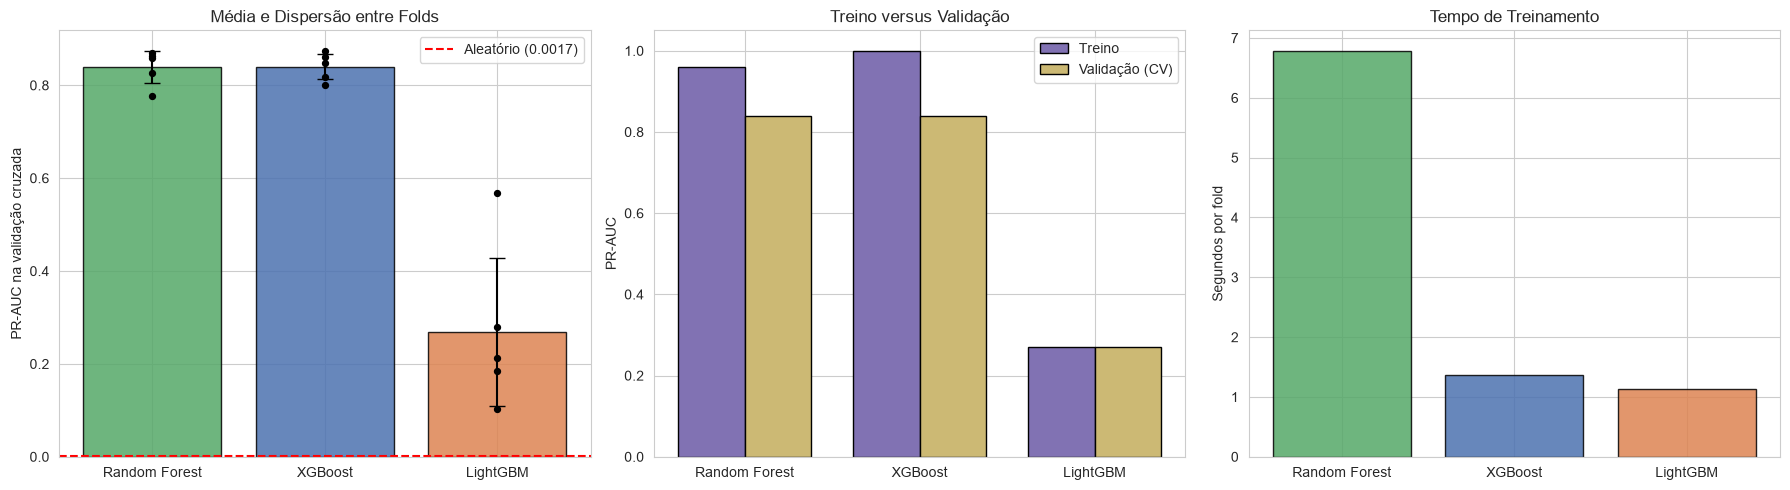

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
nomes = list(tabela_ref["Modelo"])
x = np.arange(len(nomes))

axes[0].bar(nomes, tabela_ref["AP CV (média)"], yerr=tabela_ref["AP CV (dp)"], capsize=6,
            color=["#55A868", "#4C72B0", "#DD8452"], edgecolor="black", alpha=0.85)
for i, alg in enumerate(nomes):
    axes[0].scatter([i] * N_FOLDS, resultados_ref[alg]["scores_folds"], color="black", s=18, zorder=3)
axes[0].axhline(PREVALENCIA, color="red", linestyle="--", label=f"Aleatório ({PREVALENCIA:.4f})")
axes[0].set_ylabel("PR-AUC na validação cruzada")
axes[0].set_title("Média e Dispersão entre Folds")
axes[0].legend()

largura = 0.38
axes[1].bar(x - largura / 2, tabela_ref["AP treino"], largura, label="Treino", color="#8172B3", edgecolor="black")
axes[1].bar(x + largura / 2, tabela_ref["AP CV (média)"], largura, label="Validação (CV)", color="#CCB974", edgecolor="black")
axes[1].set_xticks(x)
axes[1].set_xticklabels(nomes)
axes[1].set_ylabel("PR-AUC")
axes[1].set_title("Treino versus Validação")
axes[1].legend()

axes[2].bar(nomes, tabela_ref["Tempo por fold (s)"], color=["#55A868", "#4C72B0", "#DD8452"], edgecolor="black", alpha=0.85)
axes[2].set_ylabel("Segundos por fold")
axes[2].set_title("Tempo de Treinamento")

plt.tight_layout()
plt.show()

In [20]:
print("Diagnóstico inicial por modelo:")
for alg, r in resultados_ref.items():
    gap = r["AP treino"] - r["AP CV (média)"]
    print(f"  {alg}: gap = {gap:.4f}, dp entre folds = {r['AP CV (dp)']:.4f} -> {classificar_gap(r['AP treino'], r['AP CV (média)'])}")

melhor_ref = tabela_ref.sort_values("AP CV (média)", ascending=False).iloc[0]
print(f"\nMelhor baseline na validação: {melhor_ref['Modelo']} (AP CV = {melhor_ref['AP CV (média)']:.4f})")
print(f"Ganho sobre o modelo aleatório: {melhor_ref['AP CV (média)'] / PREVALENCIA:.0f} vezes a prevalência")

Diagnóstico inicial por modelo:
  Random Forest: gap = 0.1211, dp entre folds = 0.0344 -> gap moderado, sobreajuste leve
  XGBoost: gap = 0.1597, dp entre folds = 0.0271 -> gap elevado, indício de sobreajuste
  LightGBM: gap = 0.0022, dp entre folds = 0.1595 -> desempenho de validação baixo, indício de subajuste ou de pouca informação nas variáveis

Melhor baseline na validação: XGBoost (AP CV = 0.8403)
Ganho sobre o modelo aleatório: 505 vezes a prevalência


**Interpretação**: todos os baselines ficam muito acima da referência aleatória, o que confirma que as variáveis contêm sinal de fraude. Os pontos pretos no primeiro gráfico mostram o score de cada fold e evidenciam a variabilidade causada pelo pequeno número de fraudes por fold. Diferenças menores que o desvio-padrão entre dois modelos não devem ser tratadas como superioridade.

No gráfico de treino versus validação, o gap indica o grau de ajuste excessivo: modelos de boosting tendem a ter score de treino mais alto por ajustarem erros residuais sucessivamente, e a Random Forest com profundidade limitada tende a gap menor, porém pode ficar mais próxima de subajuste. O tempo mostra que o custo computacional dos três é diferente, o que será considerado na seleção final. O objetivo desta etapa é apenas o baseline comparável. Os hiperparâmetros ainda não foram otimizados.

---
## Exercício 5 — Tuning com Grid Search e Optuna

Todo o tuning usa exclusivamente $\mathcal{D}_{\mathrm{treino}}$, o mesmo `cv` (5 folds estratificados), o mesmo pipeline e a mesma métrica principal (PR-AUC). O problema geral é

$$
\boldsymbol{\theta}^{\star}=\operatorname*{arg\,max}_{\boldsymbol{\theta}\in\Theta}\ \frac{1}{K}\sum_{k=1}^{K}S_k(\boldsymbol{\theta}),
$$

com $K=5$ e $S_k$ sendo a PR-AUC no fold de validação $k$.

### 5.1 Grid Search

As grades são pequenas e exploram os parâmetros que controlam complexidade, número de árvores e taxa de aprendizado. O custo de um Grid Search cresce multiplicativamente com cada parâmetro adicionado, por isso a grade é deliberadamente enxuta: 8 combinações por algoritmo, ou seja, 40 ajustes por modelo.

| Algoritmo | Parâmetros e valores |
|-----------|----------------------|
| Random Forest | `n_estimators` {100, 200}, `max_depth` {8, 14}, `min_samples_leaf` {1, 5} |
| XGBoost | `n_estimators` {200, 400}, `max_depth` {4, 6}, `learning_rate` {0,05, 0,1} |
| LightGBM | `n_estimators` {200, 400}, `num_leaves` {15, 63}, `learning_rate` {0,05, 0,1} |

`refit=False` é usado porque o modelo final será retreinado no Exercício 7 com os parâmetros escolhidos.

In [21]:
GRADES = {
    "Random Forest": {
        "modelo__n_estimators": [100, 200],
        "modelo__max_depth": [8, 14],
        "modelo__min_samples_leaf": [1, 5],
    },
    "XGBoost": {
        "modelo__n_estimators": [200, 400],
        "modelo__max_depth": [4, 6],
        "modelo__learning_rate": [0.05, 0.1],
    },
    "LightGBM": {
        "modelo__n_estimators": [200, 400],
        "modelo__num_leaves": [15, 63],
        "modelo__learning_rate": [0.05, 0.1],
    },
}

resultados_grid = {}

for alg, grade in GRADES.items():
    print(f"Grid Search — {alg}...")
    busca = GridSearchCV(
        criar_pipeline(alg), grade, scoring=SCORING, cv=cv,
        n_jobs=1, refit=False, return_train_score=True,
    )
    inicio = time.perf_counter()
    busca.fit(X_train, y_train)
    tempo_busca = time.perf_counter() - inicio

    cvr = pd.DataFrame(busca.cv_results_)
    i = busca.best_index_

    resultados_grid[alg] = {
        "params": {k.replace("modelo__", ""): v for k, v in busca.best_params_.items()},
        "ap_cv": float(cvr.loc[i, "mean_test_score"]),
        "dp_cv": float(cvr.loc[i, "std_test_score"]),
        "ap_treino": float(cvr.loc[i, "mean_train_score"]),
        "tempo_fold": float(cvr.loc[i, "mean_fit_time"]),
        "tempo_busca": float(tempo_busca),
        "n_avaliacoes": int(len(cvr) * N_FOLDS),
        "cv_results": cvr,
    }
    g = resultados_grid[alg]
    print(f"  Melhores parâmetros: {g['params']}")
    print(f"  AP CV = {g['ap_cv']:.4f} +/- {g['dp_cv']:.4f} | tempo da busca = {g['tempo_busca'] / 60:.1f} min")

Grid Search — Random Forest...
  Melhores parâmetros: {'max_depth': 14, 'min_samples_leaf': 1, 'n_estimators': 200}
  AP CV = 0.8436 +/- 0.0336 | tempo da busca = 6.9 min
Grid Search — XGBoost...
  Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 400}
  AP CV = 0.8465 +/- 0.0261 | tempo da busca = 1.1 min
Grid Search — LightGBM...
  Melhores parâmetros: {'learning_rate': 0.05, 'n_estimators': 400, 'num_leaves': 63}
  AP CV = 0.6648 +/- 0.0966 | tempo da busca = 1.2 min


Resumo do Grid Search:

       Modelo                                            Melhores parâmetros  AP CV (média)  AP CV (dp)  Ajustes  Tempo da busca (min)
Random Forest  {'max_depth': 14, 'min_samples_leaf': 1, 'n_estimators': 200}         0.8436      0.0336       40                6.8603
      XGBoost   {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 400}         0.8465      0.0261       40                1.0597
     LightGBM {'learning_rate': 0.05, 'n_estimators': 400, 'num_leaves': 63}         0.6648      0.0966       40                1.2364


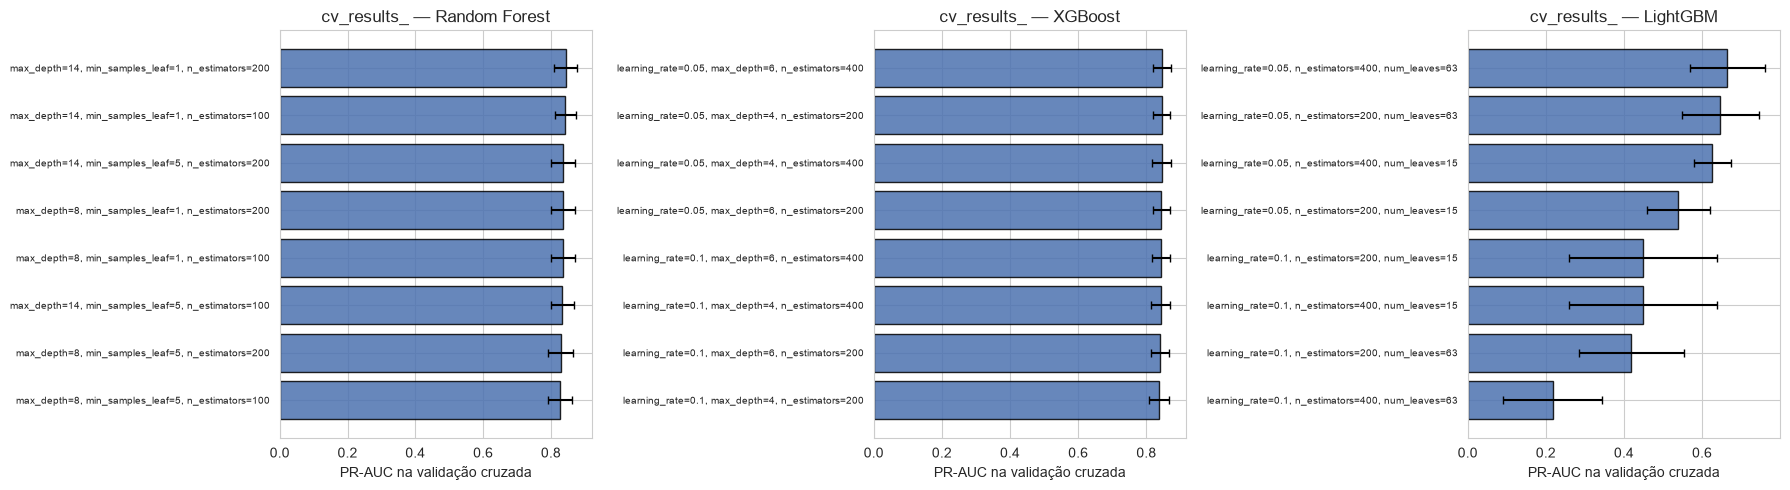

In [22]:
tabela_grid = pd.DataFrame([
    {
        "Modelo": alg,
        "Melhores parâmetros": str(g["params"]),
        "AP CV (média)": g["ap_cv"],
        "AP CV (dp)": g["dp_cv"],
        "Ajustes": g["n_avaliacoes"],
        "Tempo da busca (min)": g["tempo_busca"] / 60,
    }
    for alg, g in resultados_grid.items()
])

print("Resumo do Grid Search:\n")
print(tabela_grid.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False)
for ax, (alg, g) in zip(axes, resultados_grid.items()):
    cvr = g["cv_results"].sort_values("mean_test_score")
    rotulos = [
        ", ".join(f"{k.replace('param_modelo__', '')}={v}" for k, v in linha.items() if k.startswith("param_modelo__"))
        for _, linha in cvr.iterrows()
    ]
    ax.barh(range(len(cvr)), cvr["mean_test_score"], xerr=cvr["std_test_score"], capsize=3,
            color="#4C72B0", edgecolor="black", alpha=0.85)
    ax.set_yticks(range(len(cvr)))
    ax.set_yticklabels(rotulos, fontsize=7)
    ax.set_xlabel("PR-AUC na validação cruzada")
    ax.set_title(f"cv_results_ — {alg}")

plt.tight_layout()
plt.show()

**Interpretação**: as barras mostram a PR-AUC média de cada combinação da grade, com o desvio-padrão entre folds como barra de erro. Quando muitas combinações ficam dentro da faixa do erro, o ganho do tuning é pequeno e a escolha entre elas é pouco informativa. A melhor combinação segundo a média nem sempre é estatisticamente distinguível das vizinhas, e esse ponto será retomado na seleção final.

### 5.2 Optuna

O Optuna usa o amostrador TPE (Tree-structured Parzen Estimator), que concentra as próximas tentativas em regiões promissoras do espaço de busca. A função objetivo é a **mesma métrica principal** (PR-AUC média nos mesmos 5 folds e no mesmo pipeline). Cada algoritmo recebe **20 trials** (`N_TRIALS`), e `seed=42` torna a busca reprodutível.

Os espaços de busca são mais amplos que as grades: além de complexidade e taxa de aprendizado, incluem regularização, amostragem de linhas e colunas e o tratamento do desbalanceamento (`class_weight` ou `scale_pos_weight`).

| Algoritmo | Espaço de busca |
|-----------|-----------------|
| Random Forest | `n_estimators` 100–250 (passo 50), `max_depth` 6–16, `min_samples_leaf` 1–10, `max_features` {sqrt, log2, 0,3}, `max_samples` 0,3–0,8, `class_weight` {None, balanced_subsample} |
| XGBoost | `n_estimators` 100–500 (passo 50), `max_depth` 3–9, `learning_rate` 0,01–0,3 (log), `subsample` 0,6–1, `colsample_bytree` 0,6–1, `min_child_weight` 1–10, `reg_lambda` 0,01–10 (log), `scale_pos_weight` {1, 10, 50} |
| LightGBM | `n_estimators` 100–500 (passo 50), `num_leaves` 15–127, `learning_rate` 0,01–0,3 (log), `min_child_samples` 5–100, `subsample` 0,6–1, `colsample_bytree` 0,6–1, `reg_lambda` 0,01–10 (log), `class_weight` {None, balanced} |

Para a Random Forest, `max_samples` limita o tamanho da amostra bootstrap de cada árvore, o que reduz o custo por trial sem alterar o protocolo de avaliação.

In [23]:
def espaco_rf(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 250, step=50),
        "max_depth": trial.suggest_int("max_depth", 6, 16),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3]),
        "max_samples": trial.suggest_float("max_samples", 0.3, 0.8),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced_subsample"]),
    }

def espaco_xgb(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 9),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.01, 10.0, log=True),
        "scale_pos_weight": trial.suggest_categorical("scale_pos_weight", [1, 10, 50]),
    }

def espaco_lgbm(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.01, 10.0, log=True),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
    }

ESPACOS = {
    "Random Forest": espaco_rf,
    "XGBoost": espaco_xgb,
    "LightGBM": espaco_lgbm,
}

def otimizar(algoritmo, funcao_espaco):
    def objetivo(trial):
        params = funcao_espaco(trial)
        res = cross_validate(
            criar_pipeline(algoritmo, params), X_train, y_train, cv=cv,
            scoring=SCORING, return_train_score=True, n_jobs=1,
        )
        trial.set_user_attr("cv_dp", float(res["test_score"].std()))
        trial.set_user_attr("ap_treino", float(res["train_score"].mean()))
        trial.set_user_attr("tempo_fold", float(res["fit_time"].mean()))
        return float(res["test_score"].mean())

    estudo = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        study_name=algoritmo,
    )
    inicio = time.perf_counter()
    estudo.optimize(objetivo, n_trials=N_TRIALS)
    return estudo, time.perf_counter() - inicio

resultados_optuna = {}

for alg, espaco in ESPACOS.items():
    print(f"Optuna — {alg} ({N_TRIALS} trials)...")
    estudo, tempo_busca = otimizar(alg, espaco)
    melhor = estudo.best_trial
    resultados_optuna[alg] = {
        "params": dict(estudo.best_params),
        "ap_cv": float(melhor.value),
        "dp_cv": float(melhor.user_attrs["cv_dp"]),
        "ap_treino": float(melhor.user_attrs["ap_treino"]),
        "tempo_fold": float(melhor.user_attrs["tempo_fold"]),
        "tempo_busca": float(tempo_busca),
        "n_avaliacoes": int(N_TRIALS * N_FOLDS),
        "estudo": estudo,
        "importancias": optuna.importance.get_param_importances(estudo),
    }
    o = resultados_optuna[alg]
    print(f"  Melhores parâmetros: {o['params']}")
    print(f"  AP CV = {o['ap_cv']:.4f} +/- {o['dp_cv']:.4f} | tempo da busca = {o['tempo_busca'] / 60:.1f} min")

Optuna — Random Forest (20 trials)...
  Melhores parâmetros: {'n_estimators': 200, 'max_depth': 11, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_samples': 0.7339536628805249, 'class_weight': None}
  AP CV = 0.8401 +/- 0.0336 | tempo da busca = 19.9 min
Optuna — XGBoost (20 trials)...
  Melhores parâmetros: {'n_estimators': 450, 'max_depth': 6, 'learning_rate': 0.03498232418014451, 'subsample': 0.6679523489472632, 'colsample_bytree': 0.7095872243327693, 'min_child_weight': 1, 'reg_lambda': 1.1670284406264186, 'scale_pos_weight': 10}
  AP CV = 0.8552 +/- 0.0300 | tempo da busca = 3.4 min
Optuna — LightGBM (20 trials)...
  Melhores parâmetros: {'n_estimators': 150, 'num_leaves': 89, 'learning_rate': 0.07730660799988934, 'min_child_samples': 62, 'subsample': 0.8456333152432552, 'colsample_bytree': 0.612351608102734, 'reg_lambda': 0.055721520074294005, 'class_weight': 'balanced'}
  AP CV = 0.8549 +/- 0.0308 | tempo da busca = 2.8 min


Resumo do Optuna:

       Modelo                                                                                                                                                                                                                            Melhores parâmetros  AP CV (média)  AP CV (dp)  Trials  Tempo da busca (min)
Random Forest                                                                                                    {'n_estimators': 200, 'max_depth': 11, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_samples': 0.7339536628805249, 'class_weight': None}         0.8401      0.0336      20               19.8979
      XGBoost          {'n_estimators': 450, 'max_depth': 6, 'learning_rate': 0.03498232418014451, 'subsample': 0.6679523489472632, 'colsample_bytree': 0.7095872243327693, 'min_child_weight': 1, 'reg_lambda': 1.1670284406264186, 'scale_pos_weight': 10}         0.8552      0.0300      20                3.3773
     LightGBM {'n_estimators': 150, 'num_leaves': 8

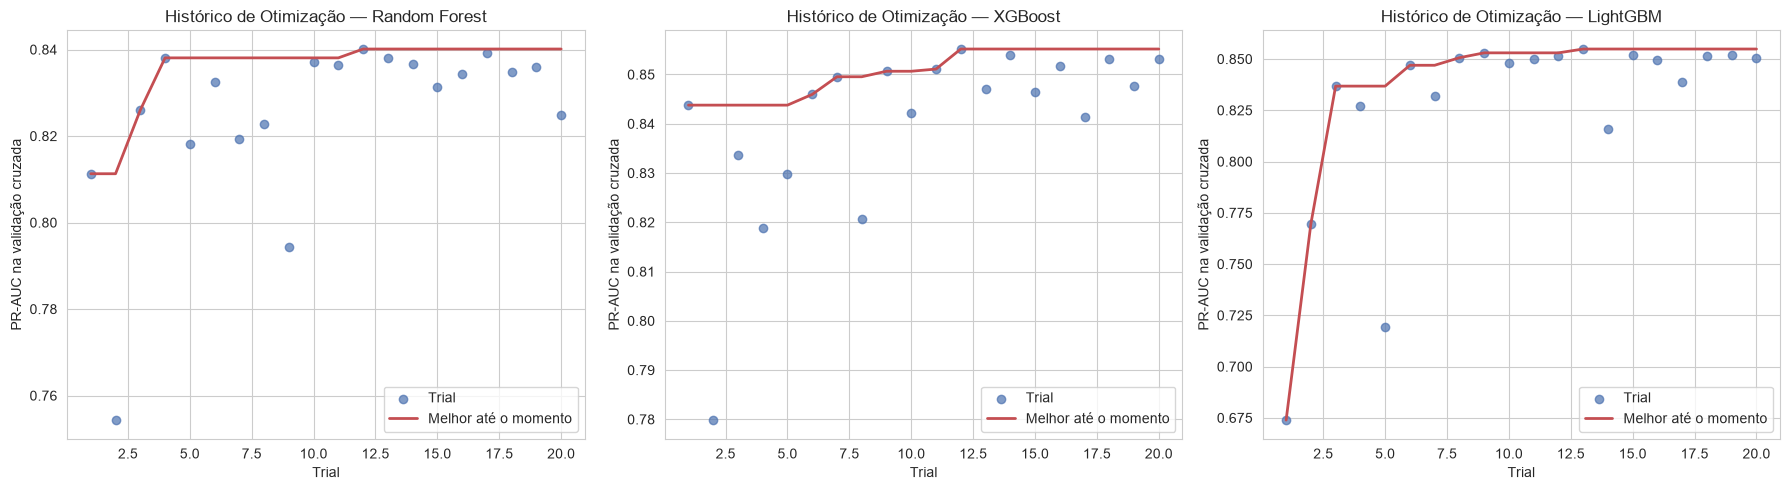

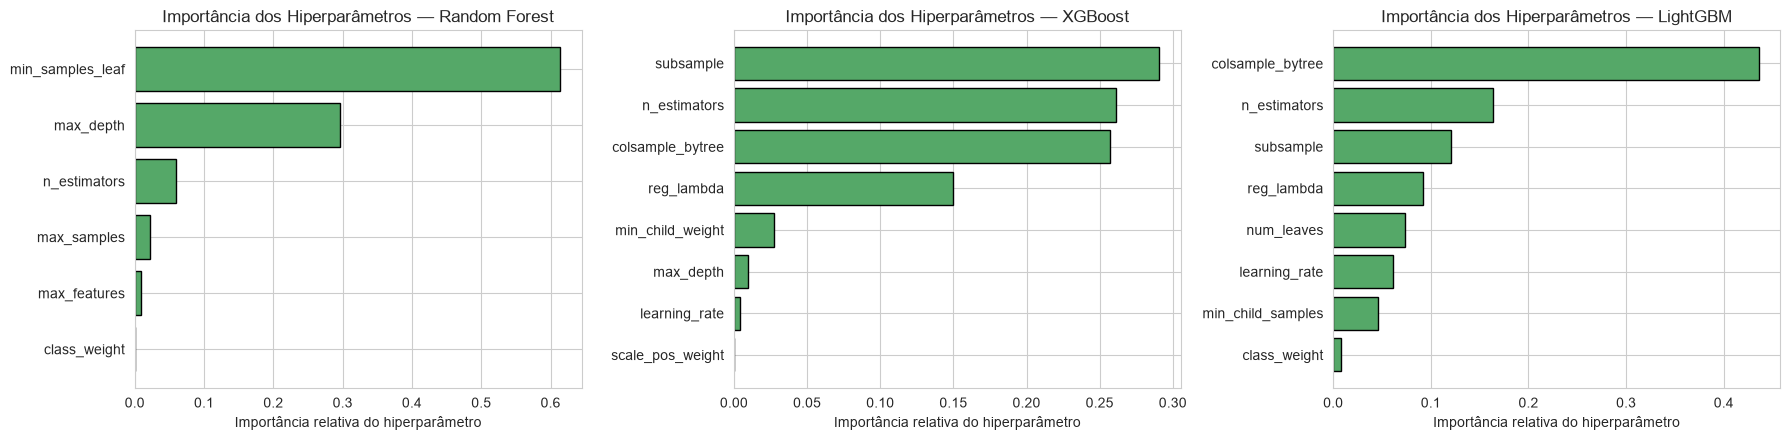

In [24]:
tabela_optuna = pd.DataFrame([
    {
        "Modelo": alg,
        "Melhores parâmetros": str(o["params"]),
        "AP CV (média)": o["ap_cv"],
        "AP CV (dp)": o["dp_cv"],
        "Trials": N_TRIALS,
        "Tempo da busca (min)": o["tempo_busca"] / 60,
    }
    for alg, o in resultados_optuna.items()
])

print("Resumo do Optuna:\n")
print(tabela_optuna.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (alg, o) in zip(axes, resultados_optuna.items()):
    valores = np.array([t.value for t in o["estudo"].trials])
    ax.scatter(range(1, len(valores) + 1), valores, color="#4C72B0", alpha=0.7, label="Trial")
    ax.plot(range(1, len(valores) + 1), np.maximum.accumulate(valores), color="#C44E52", linewidth=2, label="Melhor até o momento")
    ax.set_xlabel("Trial")
    ax.set_ylabel("PR-AUC na validação cruzada")
    ax.set_title(f"Histórico de Otimização — {alg}")
    ax.legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, (alg, o) in zip(axes, resultados_optuna.items()):
    imp = pd.Series(o["importancias"]).sort_values()
    ax.barh(imp.index, imp.values, color="#55A868", edgecolor="black")
    ax.set_xlabel("Importância relativa do hiperparâmetro")
    ax.set_title(f"Importância dos Hiperparâmetros — {alg}")

plt.tight_layout()
plt.show()

**Interpretação**: a linha vermelha do histórico mostra o melhor score acumulado. Uma curva que sobe rápido e estabiliza indica que o TPE encontrou rapidamente a região boa; uma curva que continua subindo até o último trial indica que mais trials ainda poderiam melhorar o resultado. A dispersão dos pontos revela a sensibilidade do modelo aos hiperparâmetros: pontos muito abaixo da linha correspondem a configurações ruins que o Grid Search, por ter grade fixa, nem sempre inclui ou evita.

O gráfico de importância dos hiperparâmetros indica quais deles mais influenciaram a PR-AUC dentro dos trials executados. Com apenas 20 trials, essa estimativa é aproximada e deve ser lida como tendência, não como medida precisa.

### 5.3 Comparação entre Grid Search e Optuna

       Modelo  Estratégia  AP CV (melhor)  AP CV (dp)  Média da busca  Dp da busca  Ajustes  Tempo (min)
Random Forest Grid Search          0.8436      0.0336          0.8353       0.0058       40       6.8603
Random Forest      Optuna          0.8401      0.0336          0.8253       0.0197      100      19.8979
      XGBoost Grid Search          0.8465      0.0261          0.8429       0.0029       40       1.0597
      XGBoost      Optuna          0.8552      0.0300          0.8408       0.0173      100       3.3773
     LightGBM Grid Search          0.6648      0.0966          0.5015       0.1501       40       1.2364
     LightGBM      Optuna          0.8549      0.0308          0.8262       0.0477      100       2.7931


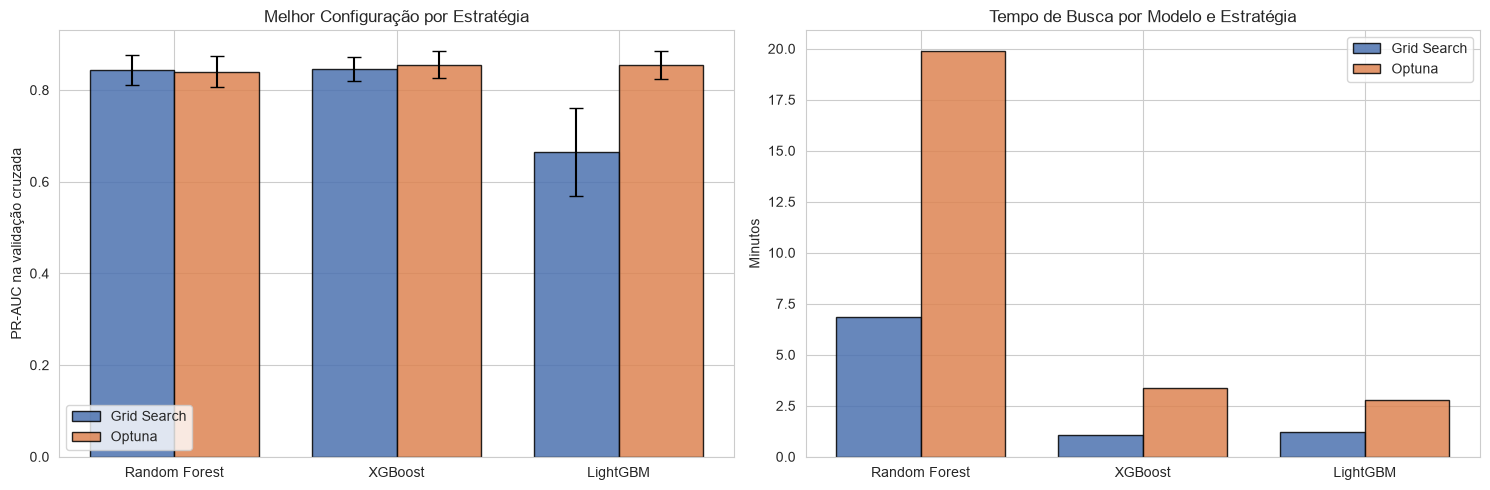

In [25]:
linhas = []
for alg in CLASSES:
    g = resultados_grid[alg]
    o = resultados_optuna[alg]
    scores_grid = g["cv_results"]["mean_test_score"]
    scores_trials = np.array([t.value for t in o["estudo"].trials])
    linhas.append({
        "Modelo": alg, "Estratégia": "Grid Search",
        "AP CV (melhor)": g["ap_cv"], "AP CV (dp)": g["dp_cv"],
        "Média da busca": scores_grid.mean(), "Dp da busca": scores_grid.std(),
        "Ajustes": g["n_avaliacoes"], "Tempo (min)": g["tempo_busca"] / 60,
    })
    linhas.append({
        "Modelo": alg, "Estratégia": "Optuna",
        "AP CV (melhor)": o["ap_cv"], "AP CV (dp)": o["dp_cv"],
        "Média da busca": scores_trials.mean(), "Dp da busca": scores_trials.std(),
        "Ajustes": o["n_avaliacoes"], "Tempo (min)": o["tempo_busca"] / 60,
    })

tabela_busca = pd.DataFrame(linhas)
print(tabela_busca.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(CLASSES))
largura = 0.38

for deslocamento, estrategia, cor in [(-largura / 2, "Grid Search", "#4C72B0"), (largura / 2, "Optuna", "#DD8452")]:
    sub = tabela_busca[tabela_busca["Estratégia"] == estrategia]
    axes[0].bar(x + deslocamento, sub["AP CV (melhor)"], largura, yerr=sub["AP CV (dp)"], capsize=5,
                label=estrategia, color=cor, edgecolor="black", alpha=0.85)
    axes[1].bar(x + deslocamento, sub["Tempo (min)"], largura, label=estrategia, color=cor, edgecolor="black", alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(list(CLASSES))
axes[0].set_ylabel("PR-AUC na validação cruzada")
axes[0].set_title("Melhor Configuração por Estratégia")
axes[0].legend()

axes[1].set_xticks(x)
axes[1].set_xticklabels(list(CLASSES))
axes[1].set_ylabel("Minutos")
axes[1].set_title("Tempo de Busca por Modelo e Estratégia")
axes[1].legend()

plt.tight_layout()
plt.show()

In [26]:
print("Comparação entre estratégias:")
for alg in CLASSES:
    g = resultados_grid[alg]
    o = resultados_optuna[alg]
    dif = o["ap_cv"] - g["ap_cv"]
    dp_max = max(g["dp_cv"], o["dp_cv"])
    veredito = "diferença dentro da variabilidade entre folds" if abs(dif) <= dp_max else "diferença maior que a variabilidade entre folds"
    print(f"  {alg}: Optuna - Grid = {dif:+.4f} ({veredito}) | custo Optuna/Grid = {o['tempo_busca'] / g['tempo_busca']:.2f}x")

Comparação entre estratégias:
  Random Forest: Optuna - Grid = -0.0035 (diferença dentro da variabilidade entre folds) | custo Optuna/Grid = 2.90x
  XGBoost: Optuna - Grid = +0.0086 (diferença dentro da variabilidade entre folds) | custo Optuna/Grid = 3.19x
  LightGBM: Optuna - Grid = +0.1901 (diferença maior que a variabilidade entre folds) | custo Optuna/Grid = 2.26x


**Interpretação**: a comparação considera três eixos e não apenas qual número ficou maior.

- **Qualidade**: se a diferença entre as estratégias é menor que o desvio-padrão entre folds, a vantagem de uma sobre a outra não é conclusiva. Como o Optuna explora espaço maior (incluindo regularização e tratamento de desbalanceamento), ele tem chance de encontrar soluções que a grade fixa não contém.
- **Custo**: o Grid Search paga por todas as combinações da grade e escala mal com o número de parâmetros. O Optuna tem custo controlado diretamente por `N_TRIALS`, e o custo por trial varia conforme os hiperparâmetros sorteados (por exemplo, mais árvores e maior profundidade custam mais).
- **Estabilidade e comportamento da busca**: o Grid Search é determinístico e fácil de auditar, e sua média e dispersão mostram o "relevo" da grade. O Optuna, guiado pelo TPE, depende da semente e do número de trials, e sua média de busca tende a ser mais alta ou mais baixa conforme concentra tentativas em regiões boas ou explora regiões ruins. Os dois resultados serão levados juntos à seleção do Exercício 6, que usa as mesmas regras para todas as configurações.

---
## Exercício 6 — Escolha do Melhor Modelo e Análise de Overfitting/Underfitting

A escolha usa **somente** resultados de treino e validação cruzada. O conjunto de teste continua intocado.

### 6.1 Tabela final com as nove configurações

Baseline, melhor Grid Search e melhor Optuna para cada um dos três algoritmos, todas avaliadas com os mesmos folds e a mesma métrica.

In [47]:
linhas = []
for alg in CLASSES:
    r = resultados_ref[alg]
    g = resultados_grid[alg]
    o = resultados_optuna[alg]
    linhas.append({"Algoritmo": alg, "Estratégia": "Baseline", "AP treino": r["AP treino"],
                   "AP CV (média)": r["AP CV (média)"], "AP CV (dp)": r["AP CV (dp)"],
                   "Tempo por fold (s)": r["Tempo por fold (s)"], "params": {}})
    linhas.append({"Algoritmo": alg, "Estratégia": "Grid Search", "AP treino": g["ap_treino"],
                   "AP CV (média)": g["ap_cv"], "AP CV (dp)": g["dp_cv"],
                   "Tempo por fold (s)": g["tempo_fold"], "params": g["params"]})
    linhas.append({"Algoritmo": alg, "Estratégia": "Optuna", "AP treino": o["ap_treino"],
                   "AP CV (média)": o["ap_cv"], "AP CV (dp)": o["dp_cv"],
                   "Tempo por fold (s)": o["tempo_fold"], "params": o["params"]})

tabela_final = pd.DataFrame(linhas)
tabela_final["Gap (treino - CV)"] = tabela_final["AP treino"] - tabela_final["AP CV (média)"]
tabela_final["Configuração"] = tabela_final["Algoritmo"] + " - " + tabela_final["Estratégia"]
tabela_final["Diagnóstico"] = [classificar_gap(a, b) for a, b in zip(tabela_final["AP treino"], tabela_final["AP CV (média)"])]

colunas_exibicao = ["Configuração", "AP treino", "AP CV (média)", "AP CV (dp)", "Gap (treino - CV)", "Tempo por fold (s)"]
print(f"Total de configurações: {len(tabela_final)}\n")
print(tabela_final[colunas_exibicao].round(4).to_string(index=False))

Total de configurações: 9

               Configuração  AP treino  AP CV (média)  AP CV (dp)  Gap (treino - CV)  Tempo por fold (s)
   Random Forest - Baseline     0.9605         0.8394      0.0344             0.1211              6.7869
Random Forest - Grid Search     0.9948         0.8436      0.0336             0.1512             15.6974
     Random Forest - Optuna     0.9792         0.8401      0.0336             0.1391             18.4185
         XGBoost - Baseline     1.0000         0.8403      0.0271             0.1597              1.3602
      XGBoost - Grid Search     1.0000         0.8465      0.0261             0.1535              1.7784
           XGBoost - Optuna     1.0000         0.8552      0.0300             0.1448              2.4427
        LightGBM - Baseline     0.2715         0.2694      0.1595             0.0022              1.1348
     LightGBM - Grid Search     0.8968         0.6648      0.0966             0.2320              1.8247
          LightGBM - Optuna 

### 6.2 Regra de seleção

A regra foi definida de forma a depender somente da validação cruzada:

1. Calcular a PR-AUC média na validação cruzada das nove configurações, todas com os mesmos folds.
2. Escolher a configuração de **maior PR-AUC média**.
3. O gap treino-validação e o tempo de ajuste são reportados para diagnóstico, mas não entram na decisão.

In [49]:
idx_melhor = tabela_final["AP CV (média)"].idxmax()
melhor_media = tabela_final.loc[idx_melhor, "AP CV (média)"]
dp_do_melhor = tabela_final.loc[idx_melhor, "AP CV (dp)"]
corte = melhor_media - dp_do_melhor

candidatas = tabela_final[tabela_final["AP CV (média)"] >= corte].copy()
escolhida = tabela_final.loc[idx_melhor] 

ALG_FINAL = escolhida["Algoritmo"]
PARAMS_FINAL = dict(escolhida["params"])
NOME_FINAL = escolhida["Configuração"]

print(f"Maior PR-AUC média: {tabela_final.loc[idx_melhor, 'Configuração']} ({melhor_media:.4f} +/- {dp_do_melhor:.4f})")
print(f"Corte de candidatura (média - 1 dp): {corte:.4f}")
print(f"\nConfigurações candidatas ({len(candidatas)}):")
print(candidatas[colunas_exibicao].round(4).to_string(index=False))

print(f"\nConfiguração promovida ao teste final: {NOME_FINAL}")
print(f"Hiperparâmetros além da referência: {PARAMS_FINAL if PARAMS_FINAL else 'nenhum (usa a configuração de referência)'}")
print(f"AP CV = {escolhida['AP CV (média)']:.4f} +/- {escolhida['AP CV (dp)']:.4f} | gap = {escolhida['Gap (treino - CV)']:.4f}")
print(f"Diagnóstico: {escolhida['Diagnóstico']}")

Maior PR-AUC média: XGBoost - Optuna (0.8552 +/- 0.0300)
Corte de candidatura (média - 1 dp): 0.8252

Configurações candidatas (7):
               Configuração  AP treino  AP CV (média)  AP CV (dp)  Gap (treino - CV)  Tempo por fold (s)
   Random Forest - Baseline     0.9605         0.8394      0.0344             0.1211              6.7869
Random Forest - Grid Search     0.9948         0.8436      0.0336             0.1512             15.6974
     Random Forest - Optuna     0.9792         0.8401      0.0336             0.1391             18.4185
         XGBoost - Baseline     1.0000         0.8403      0.0271             0.1597              1.3602
      XGBoost - Grid Search     1.0000         0.8465      0.0261             0.1535              1.7784
           XGBoost - Optuna     1.0000         0.8552      0.0300             0.1448              2.4427
          LightGBM - Optuna     1.0000         0.8549      0.0308             0.1451              1.1131

Configuração promovida ao t

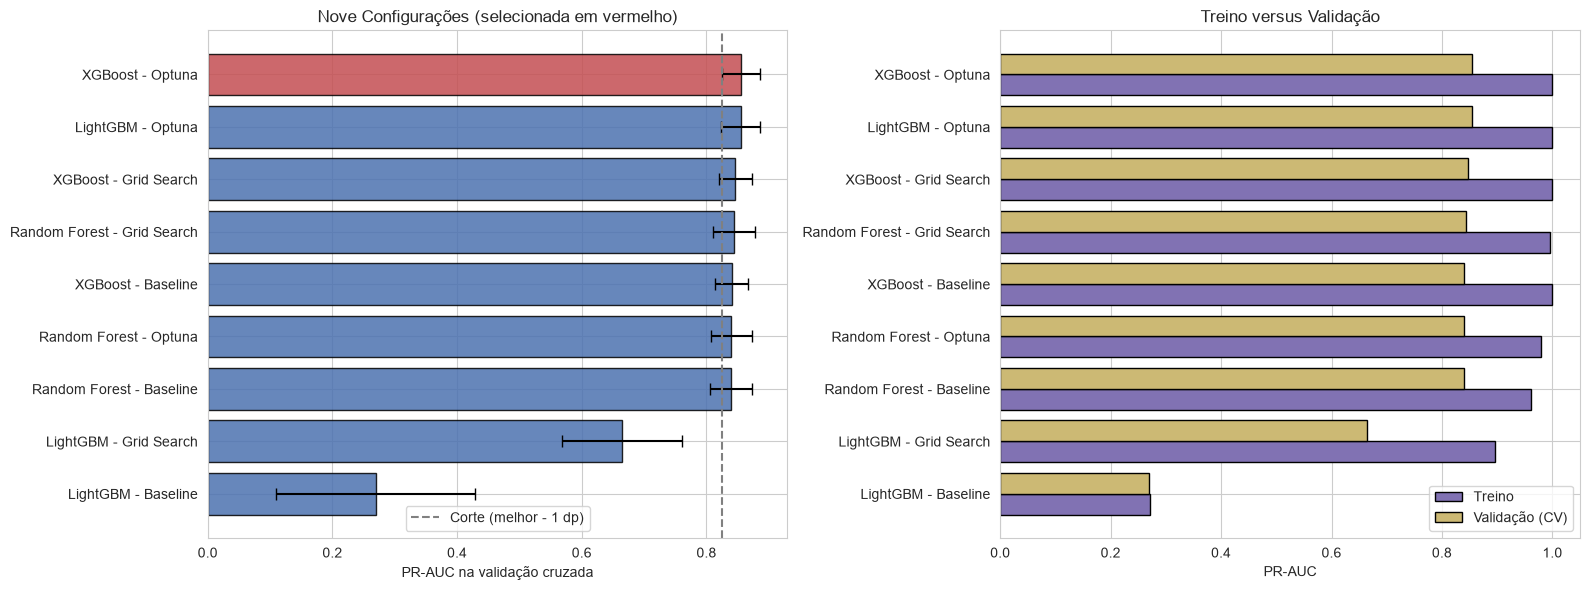

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ordem = tabela_final.sort_values("AP CV (média)")
cores = ["#C44E52" if c == NOME_FINAL else "#4C72B0" for c in ordem["Configuração"]]

axes[0].barh(ordem["Configuração"], ordem["AP CV (média)"], xerr=ordem["AP CV (dp)"], capsize=4,
             color=cores, edgecolor="black", alpha=0.85)
axes[0].axvline(corte, color="gray", linestyle="--", label="Corte (melhor - 1 dp)")
axes[0].set_xlabel("PR-AUC na validação cruzada")
axes[0].set_title("Nove Configurações (selecionada em vermelho)")
axes[0].legend()

y_pos = np.arange(len(ordem))
axes[1].barh(y_pos - 0.2, ordem["AP treino"], 0.4, label="Treino", color="#8172B3", edgecolor="black")
axes[1].barh(y_pos + 0.2, ordem["AP CV (média)"], 0.4, label="Validação (CV)", color="#CCB974", edgecolor="black")
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(ordem["Configuração"])
axes[1].set_xlabel("PR-AUC")
axes[1].set_title("Treino versus Validação")
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretação**: a escolha usa somente a métrica principal do projeto (PR-AUC na validação cruzada) e não olha o conjunto de teste. O XGBoost com Optuna teve a maior média. A diferença para as demais configurações melhores (LightGBM com Optuna, XGBoost com Grid Search) é menor que o desvio-padrão entre folds, portanto não é conclusiva; o gap treino-validação e o tempo de ajuste ficam registrados na tabela para diagnóstico, mas não entram na decisão. O teste final do Exercício 7 apenas confirma o desempenho em dados nunca vistos e não pode ser usado para trocar de modelo.

### 6.3 Curva de aprendizado e overfitting/underfitting

A curva de aprendizado avalia a configuração escolhida com frações crescentes do treino (20% a 100%) usando os mesmos folds. Ela mostra se o desempenho de validação ainda melhora com mais dados (limitação por quantidade de dados) e se treino e validação convergem (gap).

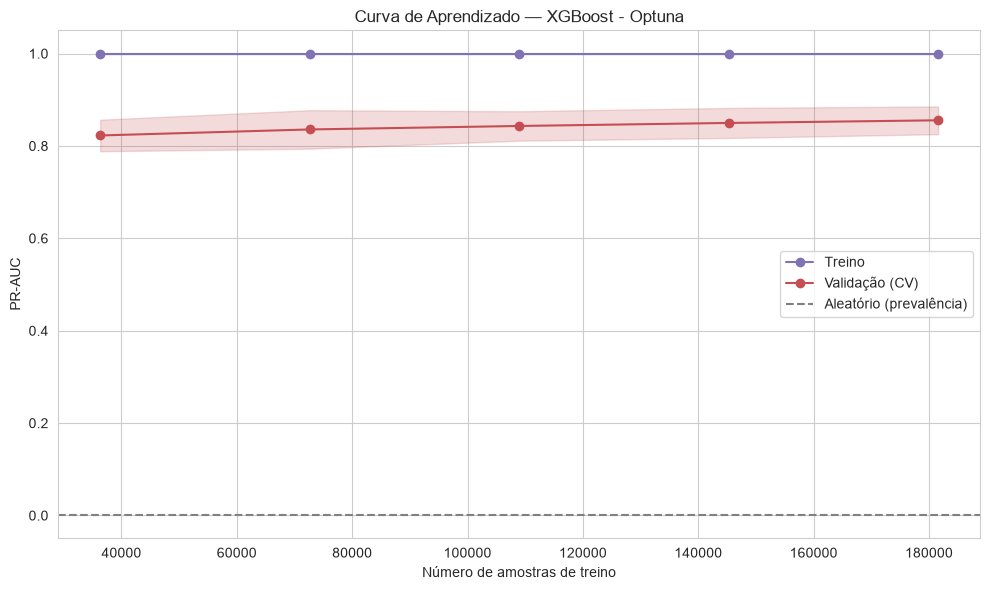

Gap final (treino - validação): 0.1446
Variação da validação entre as duas últimas frações: +0.0057
Desvio-padrão da validação na fração completa: 0.0301


In [51]:
pipe_escolhido = criar_pipeline(ALG_FINAL, PARAMS_FINAL)

tamanhos, lc_treino, lc_val = learning_curve(
    pipe_escolhido, X_train, y_train, cv=cv, scoring=SCORING,
    train_sizes=np.linspace(0.2, 1.0, 5), shuffle=True, random_state=SEED, n_jobs=1,
)

lc_treino_m, lc_treino_dp = lc_treino.mean(axis=1), lc_treino.std(axis=1)
lc_val_m, lc_val_dp = lc_val.mean(axis=1), lc_val.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(tamanhos, lc_treino_m, marker="o", color="#8172B3", label="Treino")
ax.fill_between(tamanhos, lc_treino_m - lc_treino_dp, lc_treino_m + lc_treino_dp, color="#8172B3", alpha=0.2)
ax.plot(tamanhos, lc_val_m, marker="o", color="#C44E52", label="Validação (CV)")
ax.fill_between(tamanhos, lc_val_m - lc_val_dp, lc_val_m + lc_val_dp, color="#C44E52", alpha=0.2)
ax.axhline(PREVALENCIA, color="gray", linestyle="--", label="Aleatório (prevalência)")
ax.set_xlabel("Número de amostras de treino")
ax.set_ylabel("PR-AUC")
ax.set_title(f"Curva de Aprendizado — {NOME_FINAL}")
ax.legend()
plt.tight_layout()
plt.show()

gap_final = lc_treino_m[-1] - lc_val_m[-1]
ganho_final = lc_val_m[-1] - lc_val_m[-2]
print(f"Gap final (treino - validação): {gap_final:.4f}")
print(f"Variação da validação entre as duas últimas frações: {ganho_final:+.4f}")
print(f"Desvio-padrão da validação na fração completa: {lc_val_dp[-1]:.4f}")

In [52]:
print("Leitura da curva de aprendizado:")
print(f"  Diagnóstico pelo gap: {classificar_gap(lc_treino_m[-1], lc_val_m[-1])}")
if ganho_final > lc_val_dp[-1]:
    print("  A validação ainda cresce acima do ruído entre folds: mais dados provavelmente melhorariam o modelo.")
else:
    print("  A validação praticamente estabilizou dentro do ruído entre folds: mais dados trariam ganho limitado.")
if lc_val_m[-1] < 0.50:
    print("  Score de validação baixo: há indício de subajuste ou de limite de informação nas variáveis.")

Leitura da curva de aprendizado:
  Diagnóstico pelo gap: gap moderado, sobreajuste leve
  A validação praticamente estabilizou dentro do ruído entre folds: mais dados trariam ganho limitado.


**Interpretação**: a curva de treino costuma ficar acima da de validação em modelos de árvores, e o que importa é o tamanho do gap e a tendência da curva de validação. Gap pequeno com validação estabilizada indica boa generalização; gap grande com validação ainda crescendo indica sobreajuste que mais dados poderiam atenuar; ambos os scores baixos indicam subajuste. O sombreado representa o desvio-padrão entre folds e mostra a incerteza real da estimativa. Com poucas fraudes por fold, ele pode ser considerável, e a conclusão acima deve ser lida junto com essa faixa.

### 6.4 Limiar de decisão e desempenho sobre previsões out-of-fold

O limiar que transforma probabilidade em alerta é escolhido maximizando o F1 sobre as **previsões out-of-fold** do treino (cada transação é prevista por um modelo que não a viu no ajuste). Assim o limiar não usa o teste e as métricas abaixo são estimativas honestas de validação.

In [53]:
proba_oof = cross_val_predict(
    criar_pipeline(ALG_FINAL, PARAMS_FINAL), X_train, y_train,
    cv=cv, method="predict_proba", n_jobs=1,
)[:, 1]

prec, rec, lims = precision_recall_curve(y_train, proba_oof)
f1_curva = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
LIMIAR = float(lims[np.argmax(f1_curva)])

metricas_oof = metricas_classificacao(y_train, proba_oof, LIMIAR)

print(f"Limiar escolhido (máximo F1 out-of-fold): {LIMIAR:.4f}")
print("\nMétricas out-of-fold no treino:")
for nome, valor in metricas_oof.items():
    print(f"  {nome}: {valor:.4f}")

Limiar escolhido (máximo F1 out-of-fold): 0.5966

Métricas out-of-fold no treino:
  PR-AUC (AP): 0.8535
  ROC-AUC: 0.9842
  Precision: 0.9390
  Recall: 0.8148
  F1: 0.8725
  MCC: 0.8745


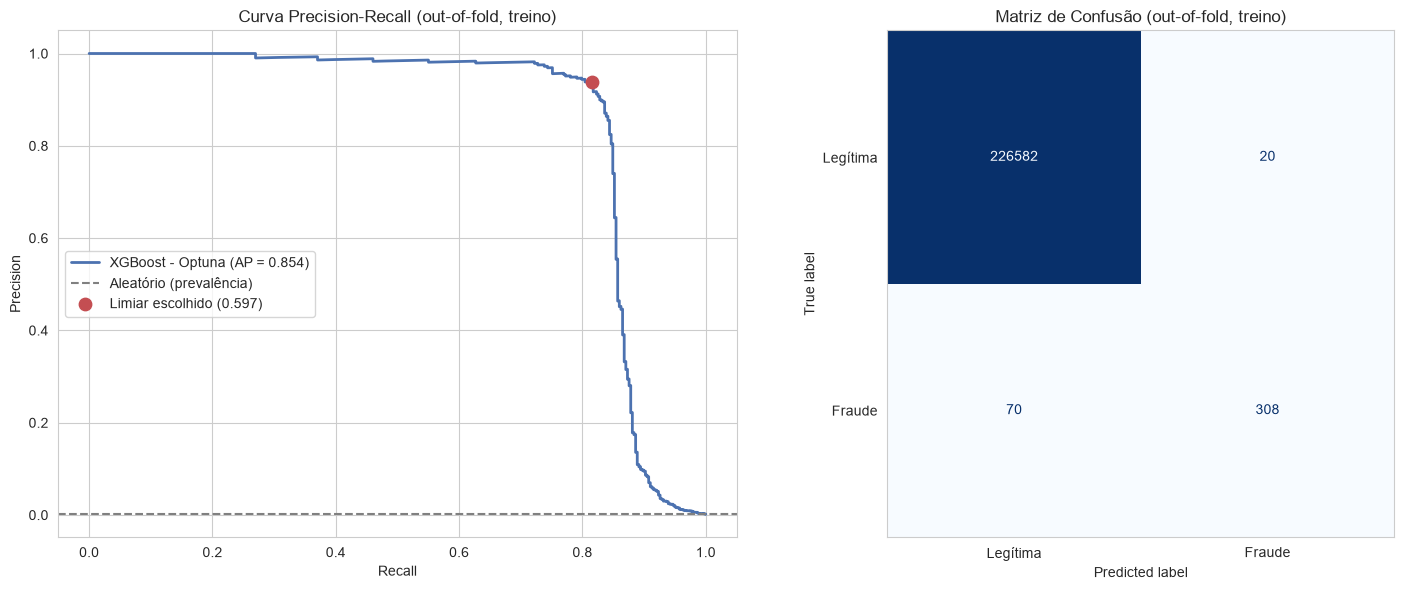

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(rec, prec, color="#4C72B0", linewidth=2, label=f"{NOME_FINAL} (AP = {metricas_oof['PR-AUC (AP)']:.3f})")
axes[0].axhline(PREVALENCIA, color="gray", linestyle="--", label="Aleatório (prevalência)")
i_lim = np.argmax(f1_curva)
axes[0].scatter(rec[i_lim], prec[i_lim], color="#C44E52", s=80, zorder=3, label=f"Limiar escolhido ({LIMIAR:.3f})")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Curva Precision-Recall (out-of-fold, treino)")
axes[0].legend()

cm_oof = confusion_matrix(y_train, (proba_oof >= LIMIAR).astype(int))
ConfusionMatrixDisplay(cm_oof, display_labels=["Legítima", "Fraude"]).plot(ax=axes[1], cmap="Blues", values_format="d", colorbar=False)
axes[1].set_title("Matriz de Confusão (out-of-fold, treino)")
axes[1].grid(False)

plt.tight_layout()
plt.show()

**Interpretação**: a curva Precision-Recall mostra o compromisso do problema: aumentar o recall (detectar mais fraudes) custa precision (mais alertas falsos). O ponto vermelho marca o limiar que equilibra os dois pelo F1, mas a escolha do limiar é, em produção, uma decisão de negócio, pois depende do custo de revisar um falso alerta versus o custo de uma fraude não detectada. A matriz de confusão traduz esse compromisso em contagens: os falsos negativos são fraudes perdidas e os falsos positivos são clientes incomodados ou revisões desnecessárias.

### 6.5 Importância das variáveis

A importância vem do atributo `feature_importances_` do estimador ajustado em todo o treino. O significado depende do algoritmo (redução de impureza na Random Forest, ganho no XGBoost e número de divisões no LightGBM), então os valores são normalizados para somar 1 e devem ser lidos como ranking relativo, e não como efeito causal.

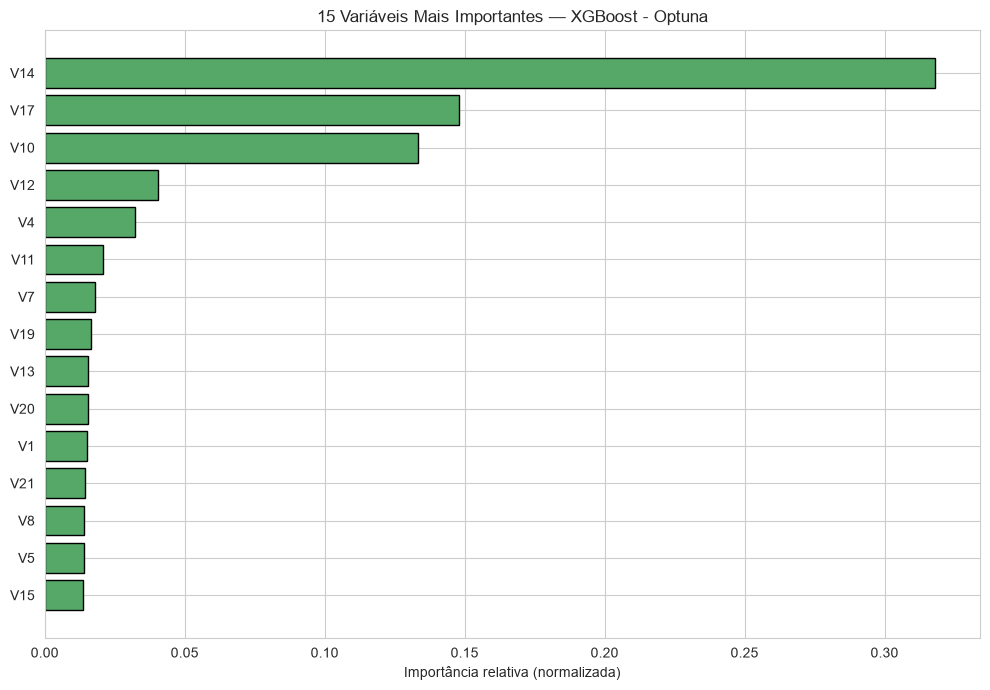

Cinco variáveis mais importantes:
V14    0.3182
V17    0.1480
V10    0.1335
V12    0.0404
V4     0.0321

Parcela da importância total nas 5 primeiras: 67.2%


In [55]:
pipe_importancia = clone(criar_pipeline(ALG_FINAL, PARAMS_FINAL)).fit(X_train, y_train)
valores = np.asarray(pipe_importancia.named_steps["modelo"].feature_importances_, dtype=float)
importancias = pd.Series(valores / valores.sum(), index=colunas_X).sort_values(ascending=False)

top = importancias.head(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top.index, top.values, color="#55A868", edgecolor="black")
ax.set_xlabel("Importância relativa (normalizada)")
ax.set_title(f"15 Variáveis Mais Importantes — {NOME_FINAL}")
plt.tight_layout()
plt.show()

print("Cinco variáveis mais importantes:")
print(importancias.head(5).round(4).to_string())
print(f"\nParcela da importância total nas 5 primeiras: {importancias.head(5).sum() * 100:.1f}%")

**Interpretação**: a importância concentrada em poucas variáveis é coerente com a análise exploratória, em que apenas parte das componentes apresentava separação visível entre as classes. Importância alta não significa causalidade, e como `V1`–`V28` são componentes anonimizados, não é possível atribuir um significado de negócio a cada uma. O ranking serve para verificar coerência do modelo e orientar a escolha das variáveis exibidas no teste de consistência e na aplicação.

---
## Exercício 7 — Teste Final, Consistência, GitHub e Streamlit

Somente agora o conjunto $\mathcal{D}_{\mathrm{teste}}$ é utilizado. A configuração escolhida no Exercício 6 é retreinada com **todo** $\mathcal{D}_{\mathrm{treino}}$ e avaliada **uma única vez** no teste, com o limiar definido no treino.

### 7.1 Avaliação final

In [56]:
modelo_final = criar_pipeline(ALG_FINAL, PARAMS_FINAL)

inicio = time.perf_counter()
modelo_final.fit(X_train, y_train)
tempo_treino_final = time.perf_counter() - inicio

proba_teste = modelo_final.predict_proba(X_test)[:, 1]
pred_teste = (proba_teste >= LIMIAR).astype(int)
metricas_teste = metricas_classificacao(y_test, proba_teste, LIMIAR)

print(f"Modelo final: {NOME_FINAL}")
print(f"Tempo de treino com todo o treino: {tempo_treino_final:.1f} s")
print(f"Limiar de decisão (definido no treino): {LIMIAR:.4f}")
print("\nMétricas no conjunto de teste:")
for nome, valor in metricas_teste.items():
    print(f"  {nome}: {valor:.4f}")

tn, fp, fn, tp = confusion_matrix(y_test, pred_teste).ravel()
print(f"\nVerdadeiros positivos: {tp} | Falsos negativos: {fn} | Falsos positivos: {fp} | Verdadeiros negativos: {tn}")

Modelo final: XGBoost - Optuna
Tempo de treino com todo o treino: 3.4 s
Limiar de decisão (definido no treino): 0.5966

Métricas no conjunto de teste:
  PR-AUC (AP): 0.8162
  ROC-AUC: 0.9810
  Precision: 0.9722
  Recall: 0.7368
  F1: 0.8383
  MCC: 0.8462

Verdadeiros positivos: 70 | Falsos negativos: 25 | Falsos positivos: 2 | Verdadeiros negativos: 56649


In [57]:
ap_cv_final = float(escolhida["AP CV (média)"])
dp_cv_final = float(escolhida["AP CV (dp)"])
ap_teste = metricas_teste["PR-AUC (AP)"]
desvios = (ap_teste - ap_cv_final) / dp_cv_final if dp_cv_final > 0 else float("nan")

comparacao = pd.DataFrame([
    {"Fonte": "Validação cruzada (treino)", "PR-AUC": ap_cv_final, "Observação": f"dp = {dp_cv_final:.4f}"},
    {"Fonte": "Teste (única avaliação)", "PR-AUC": ap_teste, "Observação": f"{desvios:+.2f} dp em relação à CV"},
])
print(comparacao.round(4).to_string(index=False))

print(f"\nF1 out-of-fold no treino: {metricas_oof['F1']:.4f} | F1 no teste: {metricas_teste['F1']:.4f}")
print(f"Recall out-of-fold no treino: {metricas_oof['Recall']:.4f} | Recall no teste: {metricas_teste['Recall']:.4f}")
print(f"Precision out-of-fold no treino: {metricas_oof['Precision']:.4f} | Precision no teste: {metricas_teste['Precision']:.4f}")

if abs(desvios) <= 2:
    print("\nO desempenho no teste é compatível com a validação cruzada (dentro de 2 desvios-padrão).")
else:
    print("\nO desempenho no teste difere da validação cruzada em mais de 2 desvios-padrão: investigar antes de concluir.")

                     Fonte  PR-AUC               Observação
Validação cruzada (treino)  0.8552              dp = 0.0300
   Teste (única avaliação)  0.8162 -1.30 dp em relação à CV

F1 out-of-fold no treino: 0.8725 | F1 no teste: 0.8383
Recall out-of-fold no treino: 0.8148 | Recall no teste: 0.7368
Precision out-of-fold no treino: 0.9390 | Precision no teste: 0.9722

O desempenho no teste é compatível com a validação cruzada (dentro de 2 desvios-padrão).


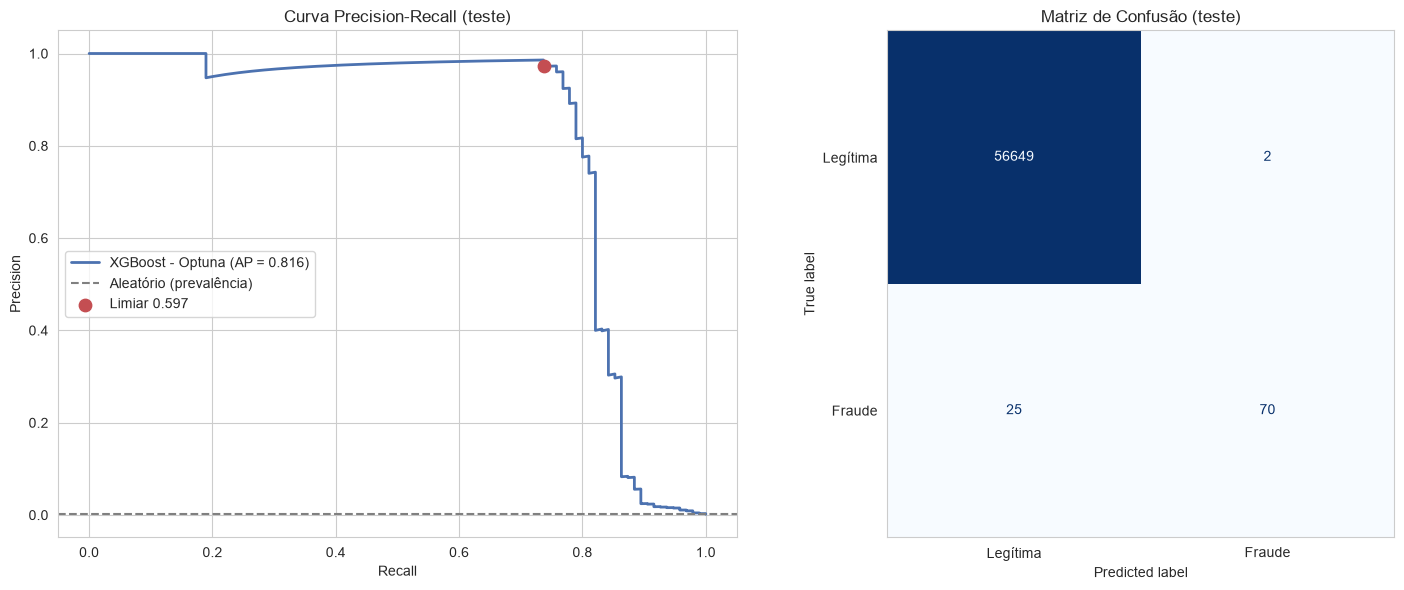

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

prec_t, rec_t, _ = precision_recall_curve(y_test, proba_teste)
axes[0].plot(rec_t, prec_t, color="#4C72B0", linewidth=2, label=f"{NOME_FINAL} (AP = {ap_teste:.3f})")
axes[0].axhline(float(y_test.mean()), color="gray", linestyle="--", label="Aleatório (prevalência)")
axes[0].scatter(metricas_teste["Recall"], metricas_teste["Precision"], color="#C44E52", s=80, zorder=3, label=f"Limiar {LIMIAR:.3f}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Curva Precision-Recall (teste)")
axes[0].legend()

ConfusionMatrixDisplay(confusion_matrix(y_test, pred_teste), display_labels=["Legítima", "Fraude"]).plot(
    ax=axes[1], cmap="Blues", values_format="d", colorbar=False)
axes[1].set_title("Matriz de Confusão (teste)")
axes[1].grid(False)

plt.tight_layout()
plt.show()

**Interpretação**: o teste é a única estimativa não enviesada por decisões de desenvolvimento. A comparação com a validação cruzada responde se a generalização observada é compatível com o esperado: diferenças dentro de poucos desvios-padrão são esperadas, porque o teste tem poucas dezenas de fraudes e, portanto, uma estimativa naturalmente ruidosa. Resultado melhor ou pior que a CV **não** autoriza voltar e trocar de modelo, pois isso transformaria o teste em parte do desenvolvimento. O ponto vermelho mostra a operação de fato adotada, com o limiar fixado no treino, e a matriz de confusão apresenta o saldo entre fraudes detectadas, fraudes perdidas e falsos alertas.

### 7.2 Teste de consistência

Seleção de observações do **conjunto de teste**, nunca vistas no treino, escolhidas por regra objetiva a partir do tipo de resultado (e não por conveniência):

| Caso | Regra de seleção |
|------|------------------|
| Fraude detectada com alta confiança | Fraude verdadeira com maior probabilidade prevista |
| Fraude detectada com confiança mediana | Fraude verdadeira na posição central entre as detectadas |
| Fraude perdida (caso difícil) | Fraude com a menor probabilidade prevista, se existir falso negativo |
| Legítima com baixa probabilidade | Transação legítima com a menor probabilidade prevista |
| Falso alerta (caso difícil) | Legítima com a maior probabilidade prevista, se existir falso positivo |

O erro individual em classificação é apresentado como $|y_i-\hat{p}_i|$, em que $\hat{p}_i$ é a probabilidade prevista de fraude.

In [59]:
df_teste = X_test.copy()
df_teste["y_real"] = y_test.values
df_teste["proba"] = proba_teste
df_teste["previsao"] = pred_teste

tp_casos = df_teste[(df_teste["y_real"] == 1) & (df_teste["previsao"] == 1)].sort_values("proba", ascending=False)
fn_casos = df_teste[(df_teste["y_real"] == 1) & (df_teste["previsao"] == 0)].sort_values("proba")
tn_casos = df_teste[(df_teste["y_real"] == 0) & (df_teste["previsao"] == 0)].sort_values("proba")
fp_casos = df_teste[(df_teste["y_real"] == 0) & (df_teste["previsao"] == 1)].sort_values("proba", ascending=False)

selecionados = []

def adicionar(rotulo, tabela, posicao):
    if len(tabela) > posicao:
        linha = tabela.iloc[posicao].copy()
        linha["rotulo"] = rotulo
        linha["indice_original"] = tabela.index[posicao]
        selecionados.append(linha)

adicionar("Fraude detectada (alta confiança)", tp_casos, 0)
adicionar("Fraude detectada (confiança mediana)", tp_casos, len(tp_casos) // 2)
adicionar("Fraude perdida (caso difícil)", fn_casos, 0)
adicionar("Legítima (baixa probabilidade)", tn_casos, 0)
adicionar("Falso alerta (caso difícil)", fp_casos, 0)
adicionar("Fraude detectada (limiar próximo)", tp_casos.sort_values("proba"), 0)
adicionar("Legítima (probabilidade mediana)", tn_casos, len(tn_casos) // 2)

exemplos = pd.DataFrame(selecionados).drop_duplicates(subset="indice_original").reset_index(drop=True)
assert len(exemplos) >= 5, "Menos de cinco observações selecionadas para o teste de consistência"

top_vars = [c for c in importancias.index if c not in ("Amount", "hora_relativa")][:3]
exemplos["erro_prob"] = (exemplos["y_real"] - exemplos["proba"]).abs()

vis = exemplos[["rotulo", "indice_original", "hora_relativa", "Amount"] + top_vars + ["y_real", "proba", "previsao", "erro_prob"]].copy()
vis["indice_original"] = vis["indice_original"].astype(int)
vis["hora_relativa"] = vis["hora_relativa"].astype(int)
vis["y_real"] = vis["y_real"].astype(int)
vis["previsao"] = vis["previsao"].astype(int)

print(f"Observações selecionadas: {len(exemplos)} (todas do conjunto de teste)")
print(f"Variáveis V mais importantes exibidas: {top_vars}\n")
print(vis.round(4).to_string(index=False))

Observações selecionadas: 7 (todas do conjunto de teste)
Variáveis V mais importantes exibidas: ['V14', 'V17', 'V10']

                              rotulo  indice_original  hora_relativa  Amount      V14      V17      V10  y_real  proba  previsao  erro_prob
   Fraude detectada (alta confiança)            42588             11  118.30 -13.6949 -20.5836 -12.8057       1 0.9999         1     0.0001
Fraude detectada (confiança mediana)           150078              2    0.01 -15.0217 -20.1656 -11.1821       1 0.9978         1     0.0022
       Fraude perdida (caso difícil)            68371             14    1.18  -0.0078  -0.8682  -0.0451       1 0.0000         0     1.0000
      Legítima (baixa probabilidade)            52251             12   40.00   0.4288  -0.4676  -0.2669       0 0.0000         0     0.0000
         Falso alerta (caso difícil)           119616             21  109.90  -7.1096 -12.1293  -5.6220       0 0.9993         1     0.9993
   Fraude detectada (limiar próximo)     

In [60]:
print("Leitura dos casos:")
for _, linha in exemplos.iterrows():
    acertou = int(linha["y_real"]) == int(linha["previsao"])
    situacao = "acerto" if acertou else "erro"
    print(f"  {linha['rotulo']}: y = {int(linha['y_real'])}, probabilidade = {linha['proba']:.4f}, previsão = {int(linha['previsao'])} ({situacao})")

n_pos_ok = int(((exemplos["y_real"] == 1) & (exemplos["previsao"] == 1)).sum())
n_neg_ok = int(((exemplos["y_real"] == 0) & (exemplos["previsao"] == 0)).sum())
n_erros = int((exemplos["y_real"] != exemplos["previsao"]).sum())
print(f"\nResumo: {n_pos_ok} fraudes detectadas, {n_neg_ok} legítimas corretas e {n_erros} erro(s) entre os casos selecionados.")

Leitura dos casos:
  Fraude detectada (alta confiança): y = 1, probabilidade = 0.9999, previsão = 1 (acerto)
  Fraude detectada (confiança mediana): y = 1, probabilidade = 0.9978, previsão = 1 (acerto)
  Fraude perdida (caso difícil): y = 1, probabilidade = 0.0000, previsão = 0 (erro)
  Legítima (baixa probabilidade): y = 0, probabilidade = 0.0000, previsão = 0 (acerto)
  Falso alerta (caso difícil): y = 0, probabilidade = 0.9993, previsão = 1 (erro)
  Fraude detectada (limiar próximo): y = 1, probabilidade = 0.7955, previsão = 1 (acerto)
  Legítima (probabilidade mediana): y = 0, probabilidade = 0.0000, previsão = 0 (acerto)

Resumo: 3 fraudes detectadas, 2 legítimas corretas e 2 erro(s) entre os casos selecionados.


**Interpretação**: nos casos de acerto, as fraudes recebem probabilidades bem acima do limiar e as transações legítimas ficam muito abaixo dele, o que é coerente com o padrão aprendido (separação nas variáveis mais importantes). Os casos difíceis, quando existem, mostram os limites do modelo: uma fraude com probabilidade baixa tem um perfil nas variáveis mais próximo do de transações legítimas, e um falso alerta é uma transação legítima que imita o padrão de fraude. A tabela mostra também as variáveis que mais pesam no modelo para essas observações, permitindo verificar se o comportamento é coerente com o ranking de importância.

### 7.3 Links do projeto

Preencha `URL_GITHUB` e `URL_STREAMLIT` após publicar o repositório e a aplicação, e execute o notebook novamente. Os links são gravados nos metadados do modelo e exibidos no aplicativo.

In [61]:
URL_GITHUB = "https://github.com/PedroH-Batista/Checkpoint-Data-Science.git"
URL_STREAMLIT = "https://checkpoint-data-science-2yayvmmk43vdea3kmx2e7t.streamlit.app/"

print("GitHub:", URL_GITHUB)
print("Streamlit:", URL_STREAMLIT)

GitHub: https://github.com/PedroH-Batista/Checkpoint-Data-Science.git
Streamlit: https://checkpoint-data-science-2yayvmmk43vdea3kmx2e7t.streamlit.app/


### 7.4 Exportação do pipeline e artefatos para a aplicação

Artefatos salvos:
- `modelo/modelo.pkl` — pipeline completo (imputador + modelo), o **mesmo objeto avaliado no teste**
- `modelo/metadados.json` — features, ranges de treino, medianas, limiar, hiperparâmetros e métricas
- `modelo/exemplos_consistencia.csv` — observações do teste de consistência, com a probabilidade calculada no notebook, para o teste de paridade com o Streamlit

A base bruta (cerca de 144 MB) e a base tratada excedem o limite de 100 MB por arquivo do GitHub e **não são versionadas**. O notebook baixa a base automaticamente e o aplicativo não depende delas.

In [62]:
CAMINHO_MODELO = "modelo/modelo.pkl"
joblib.dump(modelo_final, CAMINHO_MODELO, compress=3)
tamanho_mb = os.path.getsize(CAMINHO_MODELO) / 1e6
print(f"Pipeline salvo em {CAMINHO_MODELO} ({tamanho_mb:.1f} MB)")
if tamanho_mb > 95:
    print("ATENÇÃO: o arquivo está perto do limite de 100 MB do GitHub. Reduza n_estimators ou max_depth, ou use Git LFS.")

colunas_exemplos = ["rotulo", "indice_original"] + colunas_X + ["y_real", "proba", "previsao"]
exemplos_salvar = exemplos[colunas_exemplos].rename(columns={"proba": "proba_notebook", "previsao": "previsao_notebook"})
exemplos_salvar["indice_original"] = exemplos_salvar["indice_original"].astype(int)
exemplos_salvar["hora_relativa"] = exemplos_salvar["hora_relativa"].astype(int)
exemplos_salvar["y_real"] = exemplos_salvar["y_real"].astype(int)
exemplos_salvar["previsao_notebook"] = exemplos_salvar["previsao_notebook"].astype(int)
exemplos_salvar.to_csv("modelo/exemplos_consistencia.csv", index=False)
print(f"Exemplos de consistência salvos em modelo/exemplos_consistencia.csv ({len(exemplos_salvar)} linhas)")

metadados = {
    "modelo_nome": NOME_FINAL,
    "algoritmo": ALG_FINAL,
    "hiperparametros_alterados": {k: (v if isinstance(v, (int, float, str, bool)) or v is None else str(v)) for k, v in PARAMS_FINAL.items()},
    "data_treino": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "features": colunas_X,
    "variavel_resposta": coluna_y,
    "limiar_decisao": LIMIAR,
    "prevalencia_treino": PREVALENCIA,
    "metrica_principal": "PR-AUC (Average Precision)",
    "metricas_cv": {"AP_media": ap_cv_final, "AP_dp": dp_cv_final},
    "metricas_teste": {k: float(v) for k, v in metricas_teste.items()},
    "ranges_treino": {c: {"min": float(X_train[c].min()), "max": float(X_train[c].max())} for c in colunas_X},
    "medianas_treino": {c: float(X_train[c].median()) for c in colunas_X},
    "variaveis_mais_importantes": [str(c) for c in importancias.head(10).index],
    "links": {"github": URL_GITHUB, "streamlit": URL_STREAMLIT},
}

with open("modelo/metadados.json", "w", encoding="utf-8") as f:
    json.dump(metadados, f, ensure_ascii=False, indent=2)

print("Metadados salvos em modelo/metadados.json")
print(f"\nModelo: {NOME_FINAL}")
print(f"PR-AUC no teste: {metricas_teste['PR-AUC (AP)']:.4f}")
print(f"Limiar de decisão: {LIMIAR:.4f}")

Pipeline salvo em modelo/modelo.pkl (0.4 MB)
Exemplos de consistência salvos em modelo/exemplos_consistencia.csv (7 linhas)
Metadados salvos em modelo/metadados.json

Modelo: XGBoost - Optuna
PR-AUC no teste: 0.8162
Limiar de decisão: 0.5966


### 7.5 Teste de paridade notebook–Streamlit

A aplicação carrega `modelo.pkl` do disco, monta um `DataFrame` de uma linha com as 30 variáveis e chama `predict_proba`. O teste abaixo reproduz exatamente esse caminho a partir dos arquivos salvos e confirma que a probabilidade coincide com a calculada no notebook. Em seguida, repete o teste com as entradas arredondadas em 8 casas decimais, que é a precisão de exibição dos campos numéricos do aplicativo.

In [63]:
modelo_carregado = joblib.load("modelo/modelo.pkl")
exemplos_disco = pd.read_csv("modelo/exemplos_consistencia.csv")

print(f"{'Caso':<45}{'Notebook':>12}{'App (disco)':>14}{'App (8 casas)':>15}{'|Dif|':>12}")
diferencas = []
for _, linha in exemplos_disco.iterrows():
    entrada = pd.DataFrame([{c: float(linha[c]) for c in colunas_X}], columns=colunas_X)
    p_disco = float(modelo_carregado.predict_proba(entrada)[0, 1])
    entrada_arred = entrada.round(8)
    p_arred = float(modelo_carregado.predict_proba(entrada_arred)[0, 1])
    dif = abs(p_disco - float(linha["proba_notebook"]))
    diferencas.append(max(dif, abs(p_arred - float(linha["proba_notebook"]))))
    print(f"{linha['rotulo']:<45}{linha['proba_notebook']:>12.6f}{p_disco:>14.6f}{p_arred:>15.6f}{dif:>12.2e}")

assert max(diferencas) < 1e-4, "Divergência entre notebook e pipeline carregado do disco"
print(f"\nParidade confirmada. Maior diferença observada: {max(diferencas):.2e}")
print("Para o teste na interface, escolha um dos casos acima no seletor do app e compare a probabilidade exibida.")

Caso                                             Notebook   App (disco)  App (8 casas)       |Dif|
Fraude detectada (alta confiança)                0.999902      0.999902       0.999902    1.11e-16
Fraude detectada (confiança mediana)             0.997775      0.997775       0.997775    0.00e+00
Fraude perdida (caso difícil)                    0.000012      0.000012       0.000012    1.69e-21
Legítima (baixa probabilidade)                   0.000001      0.000001       0.000001    0.00e+00
Falso alerta (caso difícil)                      0.999304      0.999304       0.999304    0.00e+00
Fraude detectada (limiar próximo)                0.795456      0.795456       0.795456    0.00e+00
Legítima (probabilidade mediana)                 0.000014      0.000014       0.000014    0.00e+00

Paridade confirmada. Maior diferença observada: 1.11e-16
Para o teste na interface, escolha um dos casos acima no seletor do app e compare a probabilidade exibida.


**Interpretação**: a diferença nula (ou da ordem de erro numérico) mostra que o pipeline salvo reproduz exatamente a previsão do notebook, inclusive com a precisão de exibição do aplicativo. Se alguma divergência aparecesse aqui, ela viria de versões diferentes de bibliotecas, de ordem de colunas ou de um pré-processamento diferente, e precisaria ser investigada antes da entrega. O aplicativo nunca refaz o pré-processamento manualmente: usa o próprio pipeline salvo, por isso não há como a interface aplicar uma preparação diferente da avaliada.

**Procedimento para o teste de paridade na interface**: execute `streamlit run app.py`, escolha a transação **A** (a primeira linha da tabela de consistência, "Fraude detectada (alta confiança)"), mantenha os valores originais de valor e horário e abra "Verificação técnica: o app confere com o notebook?". O aplicativo mostra a probabilidade do notebook, a do aplicativo, a diferença absoluta e o status de paridade, e ela deve coincidir com a coluna "Notebook" acima.


---
## 8. Resultados e Conclusão

In [64]:
melhor_baseline = tabela_final[tabela_final["Estratégia"] == "Baseline"].sort_values("AP CV (média)", ascending=False).iloc[0]
melhor_tuning = tabela_final[tabela_final["Estratégia"] != "Baseline"].sort_values("AP CV (média)", ascending=False).iloc[0]

print("RESPOSTA ÀS PERGUNTAS DO PROJETO")
print("=" * 70)
print(f"\nÉ possível prever fraude com precisão útil? A PR-AUC do modelo final no teste é {ap_teste:.4f}, contra {float(y_test.mean()):.4f} de um classificador aleatório ({ap_teste / float(y_test.mean()):.0f} vezes a prevalência).")
print(f"No limiar {LIMIAR:.3f}, o modelo detecta {metricas_teste['Recall'] * 100:.1f}% das fraudes do teste com precisão de {metricas_teste['Precision'] * 100:.1f}% (F1 = {metricas_teste['F1']:.3f}).")

print("\nQual algoritmo e estratégia foram escolhidos?")
print(f"Configuração promovida: {NOME_FINAL}, com PR-AUC de {ap_cv_final:.4f} +/- {dp_cv_final:.4f} na validação cruzada.")
print(f"Melhor baseline: {melhor_baseline['Configuração']} ({melhor_baseline['AP CV (média)']:.4f}). Melhor após tuning: {melhor_tuning['Configuração']} ({melhor_tuning['AP CV (média)']:.4f}).")
print(f"Ganho do tuning sobre o melhor baseline: {melhor_tuning['AP CV (média)'] - melhor_baseline['AP CV (média)']:+.4f} (dp do melhor baseline: {melhor_baseline['AP CV (dp)']:.4f}).")

print("\nGeneralização")
print(f"Gap treino-CV da configuração escolhida: {escolhida['Gap (treino - CV)']:.4f} ({classificar_gap(escolhida['AP treino'], escolhida['AP CV (média)'])}).")
print(f"PR-AUC no teste versus CV: {ap_teste:.4f} versus {ap_cv_final:.4f} ({desvios:+.2f} desvios-padrão).")

print("\nVariáveis mais relevantes")
print(", ".join(f"{c} ({v * 100:.1f}%)" for c, v in importancias.head(5).items()))

print("\nLimitações")
print("- Poucas fraudes no teste: as métricas dependentes de limiar têm incerteza elevada.")
print("- V1 a V28 são anonimizadas por PCA: não há interpretação de negócio por variável.")
print("- Base de dois dias de 2013 em um único contexto: o modelo pode sofrer deriva temporal em produção.")
print("- O limiar de decisão deve refletir o custo real de falso alerta e de fraude perdida.")

RESPOSTA ÀS PERGUNTAS DO PROJETO

É possível prever fraude com precisão útil? A PR-AUC do modelo final no teste é 0.8162, contra 0.0017 de um classificador aleatório (488 vezes a prevalência).
No limiar 0.597, o modelo detecta 73.7% das fraudes do teste com precisão de 97.2% (F1 = 0.838).

Qual algoritmo e estratégia foram escolhidos?
Configuração promovida: XGBoost - Optuna, com PR-AUC de 0.8552 +/- 0.0300 na validação cruzada.
Melhor baseline: XGBoost - Baseline (0.8403). Melhor após tuning: XGBoost - Optuna (0.8552).
Ganho do tuning sobre o melhor baseline: +0.0149 (dp do melhor baseline: 0.0271).

Generalização
Gap treino-CV da configuração escolhida: 0.1448 (gap moderado, sobreajuste leve).
PR-AUC no teste versus CV: 0.8162 versus 0.8552 (-1.30 desvios-padrão).

Variáveis mais relevantes
V14 (31.8%), V17 (14.8%), V10 (13.3%), V12 (4.0%), V4 (3.2%)

Limitações
- Poucas fraudes no teste: as métricas dependentes de limiar têm incerteza elevada.
- V1 a V28 são anonimizadas por PCA: nã

In [65]:
def linha_md(*celulas):
    return "| " + " | ".join(str(c) for c in celulas) + " |"

print("TABELA PARA O README \n")
print(linha_md("Configuração", "AP treino", "AP CV (média)", "AP CV (dp)", "Gap", "Tempo por fold (s)"))
print(linha_md("---", "---", "---", "---", "---", "---"))
for _, l in tabela_final.iterrows():
    marca = " **(escolhida)**" if l["Configuração"] == NOME_FINAL else ""
    print(linha_md(l["Configuração"] + marca, f"{l['AP treino']:.4f}", f"{l['AP CV (média)']:.4f}", f"{l['AP CV (dp)']:.4f}", f"{l['Gap (treino - CV)']:.4f}", f"{l['Tempo por fold (s)']:.1f}"))

print("\nMÉTRICAS NO TESTE\n")
print(linha_md("Métrica", "Valor"))
print(linha_md("---", "---"))
for nome, valor in metricas_teste.items():
    print(linha_md(nome, f"{valor:.4f}"))
print(linha_md("Limiar de decisão", f"{LIMIAR:.4f}"))

TABELA PARA O README 

| Configuração | AP treino | AP CV (média) | AP CV (dp) | Gap | Tempo por fold (s) |
| --- | --- | --- | --- | --- | --- |
| Random Forest - Baseline | 0.9605 | 0.8394 | 0.0344 | 0.1211 | 6.8 |
| Random Forest - Grid Search | 0.9948 | 0.8436 | 0.0336 | 0.1512 | 15.7 |
| Random Forest - Optuna | 0.9792 | 0.8401 | 0.0336 | 0.1391 | 18.4 |
| XGBoost - Baseline | 1.0000 | 0.8403 | 0.0271 | 0.1597 | 1.4 |
| XGBoost - Grid Search | 1.0000 | 0.8465 | 0.0261 | 0.1535 | 1.8 |
| XGBoost - Optuna **(escolhida)** | 1.0000 | 0.8552 | 0.0300 | 0.1448 | 2.4 |
| LightGBM - Baseline | 0.2715 | 0.2694 | 0.1595 | 0.0022 | 1.1 |
| LightGBM - Grid Search | 0.8968 | 0.6648 | 0.0966 | 0.2320 | 1.8 |
| LightGBM - Optuna | 1.0000 | 0.8549 | 0.0308 | 0.1451 | 1.1 |

MÉTRICAS NO TESTE

| Métrica | Valor |
| --- | --- |
| PR-AUC (AP) | 0.8162 |
| ROC-AUC | 0.9810 |
| Precision | 0.9722 |
| Recall | 0.7368 |
| F1 | 0.8383 |
| MCC | 0.8462 |
| Limiar de decisão | 0.5966 |


---
## Referências

- BREIMAN, Leo. Random Forests. *Machine Learning*, v. 45, p. 5–32, 2001.
- CHEN, Tianqi; GUESTRIN, Carlos. XGBoost: A Scalable Tree Boosting System. *Proceedings of the 22nd ACM SIGKDD*, 2016.
- KE, Guolin et al. LightGBM: A Highly Efficient Gradient Boosting Decision Tree. *Advances in Neural Information Processing Systems*, 2017.
- AKIBA, Takuya et al. Optuna: A Next-generation Hyperparameter Optimization Framework. *Proceedings of the 25th ACM SIGKDD*, 2019.
- DAL POZZOLO, Andrea et al. Calibrating Probability with Undersampling for Unbalanced Classification. *IEEE Symposium on Computational Intelligence and Data Mining (CIDM)*, 2015.
- GÉRON, Aurélien. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. 3. ed. O'Reilly Media, 2023.
- KUHN, Max; JOHNSON, Kjell. *Feature Engineering and Selection: A Practical Approach for Predictive Models*. CRC Press, 2020.